In [26]:
#! pip install pandas
#! pip install matplotlib
#! pip install scipy
#! pip install seaborn
#! pip install nbconvert
#! pip install matplotlib-venn
#! pip install scour
! jupyter nbconvert --to HTML PoseSimilarityAnalysis.ipynb

^C


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.interpolate import griddata
import numpy as np
import torch.nn.functional as F
from tqdm import tqdm
from scipy.interpolate import LinearNDInterpolator
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../../")  # from src/notebooks/pose_analysis to src/

from util.datapipeline.EmbeddingDataset import EmbeddingDataset

pd.set_option('display.max_columns', None)

In [2]:
def compute_gaig_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=""):


    # ------------------------------------------------------------
    # Pose grid
    # ------------------------------------------------------------
    _, _, _, _, poses_ref = dataset_query[0]
    poses_ref = np.array([tuple(map(int, p)) for p in poses_ref])

    pitches = np.unique(poses_ref[:,0])
    yaws = np.unique(poses_ref[:,1])

    H = len(pitches)
    W = len(yaws)

    pitch_to_idx = {p:i for i,p in enumerate(pitches)}
    yaw_to_idx   = {y:j for j,y in enumerate(yaws)}

    grid_pitch, grid_yaw = np.meshgrid(pitches, yaws, indexing="ij")
    grid_points = np.stack([grid_pitch.ravel(), grid_yaw.ravel()], axis=1)

    cache_file = f"{prefix}_gaig_heatmap_cache.npz"
    if os.path.exists(cache_file):
        print("Loading cached heatmap:", cache_file)
        data = np.load(cache_file)
        gaig_sum = data["gaig_sum"]
        counts = data["counts"]
        heatmap_gaig = (gaig_sum / np.maximum(counts,1)) * 100
    else:
        # ------------------------------------------------------------
        # Collect ENROLLED frontal embeddings only
        # ------------------------------------------------------------
        enrolled_embeddings = []
        enrolled_labels = []

        for emb, label, _, _, poses in tqdm(dataset_enrolled, desc="Prepare Enrolled"):

            emb = F.normalize(emb, dim=-1).cpu().numpy()
            poses = [tuple(map(int, p)) for p in poses]

            for e, p in zip(emb, poses):
                pitch, yaw = p

                if pitch == 0 and yaw == 0:
                    enrolled_embeddings.append(e)
                    enrolled_labels.append(label)

        enrolled_embeddings = np.stack(enrolled_embeddings)
        enrolled_labels = np.array(enrolled_labels)
        
        enrolled_T = enrolled_embeddings.T

        # ------------------------------------------------------------
        # Pose accumulators
        # ------------------------------------------------------------
        gaig_sum = np.zeros((H,W), dtype=np.float32)
        counts  = np.zeros((H,W), dtype=np.int32)

        # ------------------------------------------------------------
        # Process QUERY one sample at a time
        # ------------------------------------------------------------
        for emb, label, _, _, poses in tqdm(dataset_query, desc="Processing Queries"):

            emb = F.normalize(emb, dim=-1).cpu().numpy()
            poses = [tuple(map(int,p)) for p in poses]

            for e, p in zip(emb, poses):

                pitch, yaw = p

                i = pitch_to_idx[pitch]
                j = yaw_to_idx[yaw]

                sims = np.dot(e, enrolled_T)

                # -----------------------------
                # GAIG computation
                # -----------------------------
                gt_indices = np.where(enrolled_labels == label)[0]
                imp_indices = np.where(enrolled_labels != label)[0]

                if len(gt_indices) > 0:
                    genuine_sim = np.max(sims[gt_indices])
                else:
                    genuine_sim = 0.0

                if len(imp_indices) > 0:
                    impostor_mean = np.mean(sims[imp_indices])
                else:
                    impostor_mean = 0.0

                gaig = (genuine_sim - impostor_mean)

                gaig_sum[i,j] += gaig
                counts[i,j] += 1

        heatmap_gaig = (gaig_sum / np.maximum(counts,1)) * 100

        np.savez_compressed(
            cache_file,
            gaig_sum=gaig_sum,
            counts=counts,
        )

    print("Saved heatmap cache:", cache_file)

    # ------------------------------------------------------------
    # Pose → heatmap index mapping (for visualization)
    # ------------------------------------------------------------
    pitch_to_idx = {p: i for i, p in enumerate(pitches)}
    yaw_to_idx   = {y: j for j, y in enumerate(yaws)}

    pose_y = np.array([pitch_to_idx[p] for p, _ in poses_ref])
    pose_x = np.array([yaw_to_idx[y]   for _, y in poses_ref])

    # ------------------------------------------------------------
    # Interpolation
    # ------------------------------------------------------------
    valid = counts.ravel() > 0
    points = grid_points[valid]
    values = np.divide(
        gaig_sum.ravel(),
        counts.ravel(),
        out=np.zeros_like(gaig_sum.ravel(), dtype=float),
        where=counts.ravel() > 0
    )[valid] * 100

    interp_gaig = LinearNDInterpolator(points, values, fill_value=np.nan)
    heatmap_gaig = interp_gaig(grid_points).reshape(H, W)

    # ------------------------------------------------------------
    # Visualization
    # ------------------------------------------------------------
    if visualize:

        raw_gaig = interp_gaig(grid_points).reshape(H, W)
        valid_mask = ~np.isnan(raw_gaig)
        heat_gaig_plot = np.ma.masked_where(~valid_mask, raw_gaig)

        plt.rcParams.update({
            "font.size": 16,
            "axes.titlesize": 26,
            "xtick.labelsize": 18,
            "ytick.labelsize": 18,
        })

        cmap_main = plt.cm.viridis.copy()
        cmap_main.set_bad(color="white")

        fig1, ax1 = plt.subplots(figsize=(22, 20))
        vmax = np.nanmax(np.abs(heat_gaig_plot))
        vmin = np.nanmin(np.abs(heat_gaig_plot))

        sns.heatmap(
            heat_gaig_plot,
            ax=ax1,
            xticklabels=yaws,
            yticklabels=pitches,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap_main,
            square=True,
            cbar_kws={"shrink": 0.8, "label": "GAIG"}
        )

        threshold = vmin + 0.25 * (vmax - vmin)
        for x, y in zip(pose_x, pose_y):
            val = heatmap_gaig[y, x]
            if x%5==0 and y%5==0:
                text_color = "white" if val < threshold else "black"
                ax1.text(
                    x + 0.5, y + 0.5,
                    f"{val:.0f}",
                    ha="center",
                    va="center",
                    fontsize=13,
                    color=text_color
                )

        ax1.set_title("Pose-Dependent Single-View GAIG with Frontal Enrollment (0°, 0°)")
        ax1.set_xlabel("Yaw")
        ax1.set_ylabel("Pitch")

        for i, label in enumerate(ax1.get_xticklabels()):
            if i % 5 != 0:
                label.set_visible(False)
        for i, label in enumerate(ax1.get_yticklabels()):
            if i % 5 != 0:
                label.set_visible(False)

        plt.savefig(f"{prefix}_gaig_heatmap.svg", bbox_inches="tight")
        plt.savefig(f"{prefix}_gaig_heatmap.jpg", dpi=200, bbox_inches="tight")

        plt.show()

    # ------------------------------------------------------------
    # Min / Max of final heatmap
    # ------------------------------------------------------------
    heatmap_min = np.nanmin(heatmap_gaig)
    heatmap_max = np.nanmax(heatmap_gaig)

    return heatmap_gaig, pitches, yaws, heatmap_min, heatmap_max

### Headpose aligned comparison

In [3]:
def compute_gaig_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix="", vmin=None, vmax=None):

    # ------------------------------------------------------------
    # Pose grid
    # ------------------------------------------------------------
    _, _, _, _, poses_ref = dataset_query[0]
    poses_ref = np.array([tuple(map(int, p)) for p in poses_ref])

    pitches = np.unique(poses_ref[:, 0])
    yaws = np.unique(poses_ref[:, 1])

    H = len(pitches)
    W = len(yaws)

    pitch_to_idx = {p: i for i, p in enumerate(pitches)}
    yaw_to_idx = {y: j for j, y in enumerate(yaws)}

    grid_pitch, grid_yaw = np.meshgrid(pitches, yaws, indexing="ij")
    grid_points = np.stack([grid_pitch.ravel(), grid_yaw.ravel()], axis=1)

    # ------------------------------------------------------------
    # Pose alignment maps (same idea as MRR)
    # ------------------------------------------------------------
    pose_to_embeddings = {}
    pose_to_labels = {}
    pose_to_T = {}

    for emb, label, _, _, poses in tqdm(dataset_enrolled, desc="Prepare Enrolled"):

        emb = F.normalize(emb, dim=-1).cpu().numpy()
        poses = [tuple(map(int, p)) for p in poses]

        for e, p in zip(emb, poses):

            if p not in pose_to_embeddings:
                pose_to_embeddings[p] = []
                pose_to_labels[p] = []

            pose_to_embeddings[p].append(e)
            pose_to_labels[p].append(label)

    # convert to numpy + transpose
    for p in pose_to_embeddings:
        pose_to_embeddings[p] = np.stack(pose_to_embeddings[p])
        pose_to_labels[p] = np.array(pose_to_labels[p])
        pose_to_T[p] = pose_to_embeddings[p].T

    # ------------------------------------------------------------
    # Pose accumulators
    # ------------------------------------------------------------
    gaig_sum = np.zeros((H, W), dtype=np.float32)
    counts = np.zeros((H, W), dtype=np.int32)

    # ------------------------------------------------------------
    # Process queries (pose-aligned GAIG)
    # ------------------------------------------------------------
    for emb, label, _, _, poses in tqdm(dataset_query, desc="Processing Queries"):

        emb = F.normalize(emb, dim=-1).cpu().numpy()
        poses = [tuple(map(int, p)) for p in poses]

        for e, p in zip(emb, poses):

            # skip if no enrolled for this pose
            if p not in pose_to_embeddings:
                continue

            pitch, yaw = p
            i = pitch_to_idx[pitch]
            j = yaw_to_idx[yaw]

            enrolled_T = pose_to_T[p]
            enrolled_labels = pose_to_labels[p]

            sims = np.dot(e, enrolled_T)

            # -----------------------------
            # GAIG (pose-restricted)
            # -----------------------------
            gt_indices = np.where(enrolled_labels == label)[0]
            imp_indices = np.where(enrolled_labels != label)[0]

            if len(gt_indices) > 0:
                genuine_sim = np.max(sims[gt_indices])
            else:
                genuine_sim = 0.0

            if len(imp_indices) > 0:
                impostor_mean = np.mean(sims[imp_indices])
            else:
                impostor_mean = 0.0

            gaig = genuine_sim - impostor_mean

            gaig_sum[i, j] += gaig
            counts[i, j] += 1

    heatmap_gaig = (gaig_sum / np.maximum(counts, 1)) * 100

    # ------------------------------------------------------------
    # Interpolation (same as your MRR style)
    # ------------------------------------------------------------
    valid = counts.ravel() > 0
    points = grid_points[valid]
    values = np.divide(
        gaig_sum.ravel(),
        counts.ravel(),
        out=np.zeros_like(gaig_sum.ravel(), dtype=float),
        where=counts.ravel() > 0
    )[valid] * 100

    interp_gaig = LinearNDInterpolator(points, values, fill_value=np.nan)
    heatmap_gaig = interp_gaig(grid_points).reshape(H, W)

    # ------------------------------------------------------------
    # Visualization
    # ------------------------------------------------------------
    if visualize:

        raw_gaig = interp_gaig(grid_points).reshape(H, W)
        valid_mask = ~np.isnan(raw_gaig)
        heat_plot = np.ma.masked_where(~valid_mask, raw_gaig)

        plt.rcParams.update({
            "font.size": 16,
            "axes.titlesize": 26,
            "xtick.labelsize": 18,
            "ytick.labelsize": 18,
        })

        cmap = plt.cm.viridis.copy()
        cmap.set_bad(color="white")

        fig, ax = plt.subplots(figsize=(22, 20))

        if vmin is None:
            vmin = np.nanmin(np.abs(heat_plot))
        if vmax is None:
            vmax = np.nanmax(np.abs(heat_plot))

        sns.heatmap(
            heat_plot,
            ax=ax,
            xticklabels=yaws,
            yticklabels=pitches,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            square=True,
            cbar_kws={"shrink": 0.8, "label": "GAIG"}
        )

        threshold = vmin + 0.25 * (vmax - vmin)

        for x in range(W):
            for y in range(H):
                if counts[y, x] == 0:
                    continue

                val = heatmap_gaig[y, x]
                if x%5==0 and y%5==0:
                    text_color = "white" if val < threshold else "black"
                    ax.text(
                        x + 0.5,
                        y + 0.5,
                        f"{val:.0f}",
                        ha="center",
                        va="center",
                        fontsize=13,
                        color=text_color
                    )

        ax.set_title("Pose-Aligned Pose-Dependent Single-View GAIG")
        ax.set_xlabel("Yaw")
        ax.set_ylabel("Pitch")

        for i, label in enumerate(ax.get_xticklabels()):
            if i % 5 != 0:
                label.set_visible(False)
        for i, label in enumerate(ax.get_yticklabels()):
            if i % 5 != 0:
                label.set_visible(False)

        plt.savefig(f"{prefix}_gaig_heatmap_aligned.svg", bbox_inches="tight")
        plt.savefig(f"{prefix}_gaig_heatmap_aligned.jpg", dpi=200, bbox_inches="tight")
        plt.show()

    return heatmap_gaig, pitches, yaws

Loading classes: 100%|██████████| 1041/1041 [02:35<00:00,  6.68it/s]


Loading cached heatmap: test_rgb_bff_crop305_emb-edgeface_xs_gaig_heatmap_cache.npz
Saved heatmap cache: test_rgb_bff_crop305_emb-edgeface_xs_gaig_heatmap_cache.npz


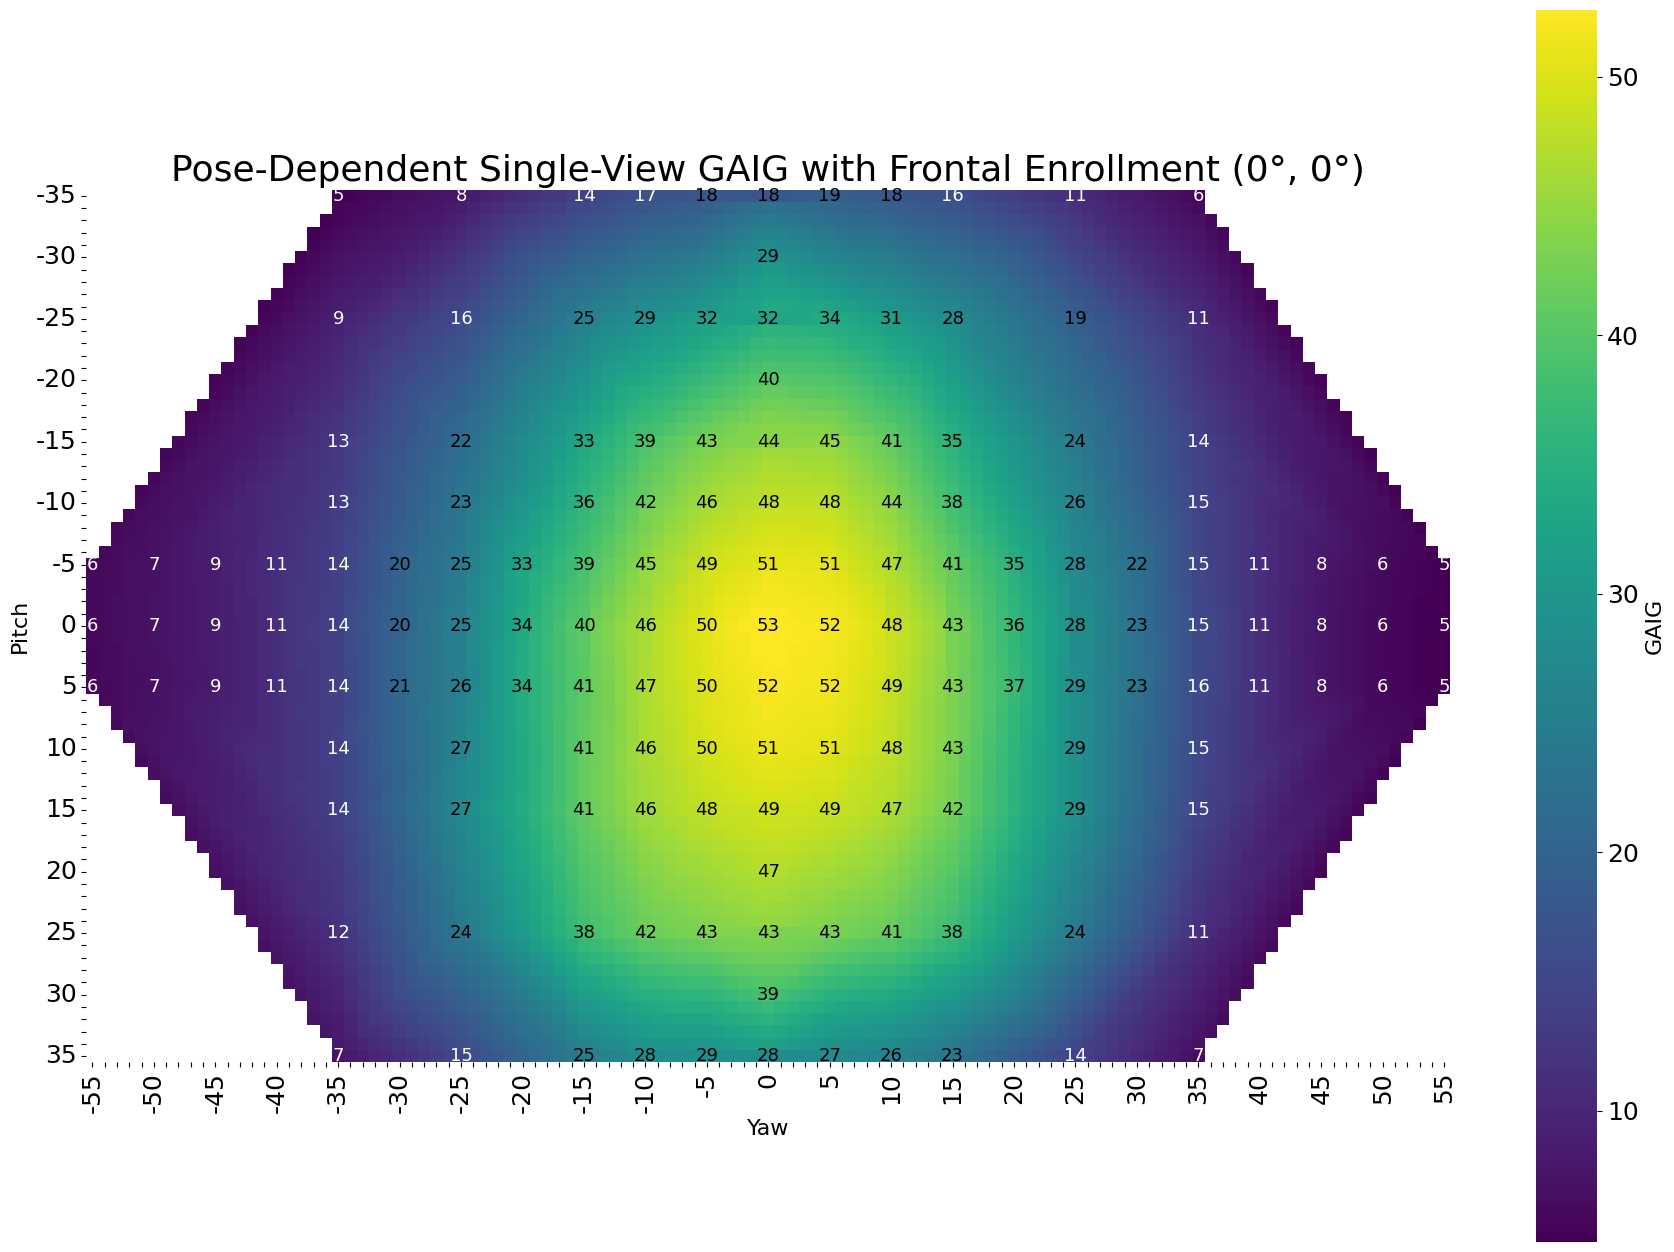

Processing Queries: 100%|██████████| 18745/18745 [16:15<00:00, 19.22it/s]


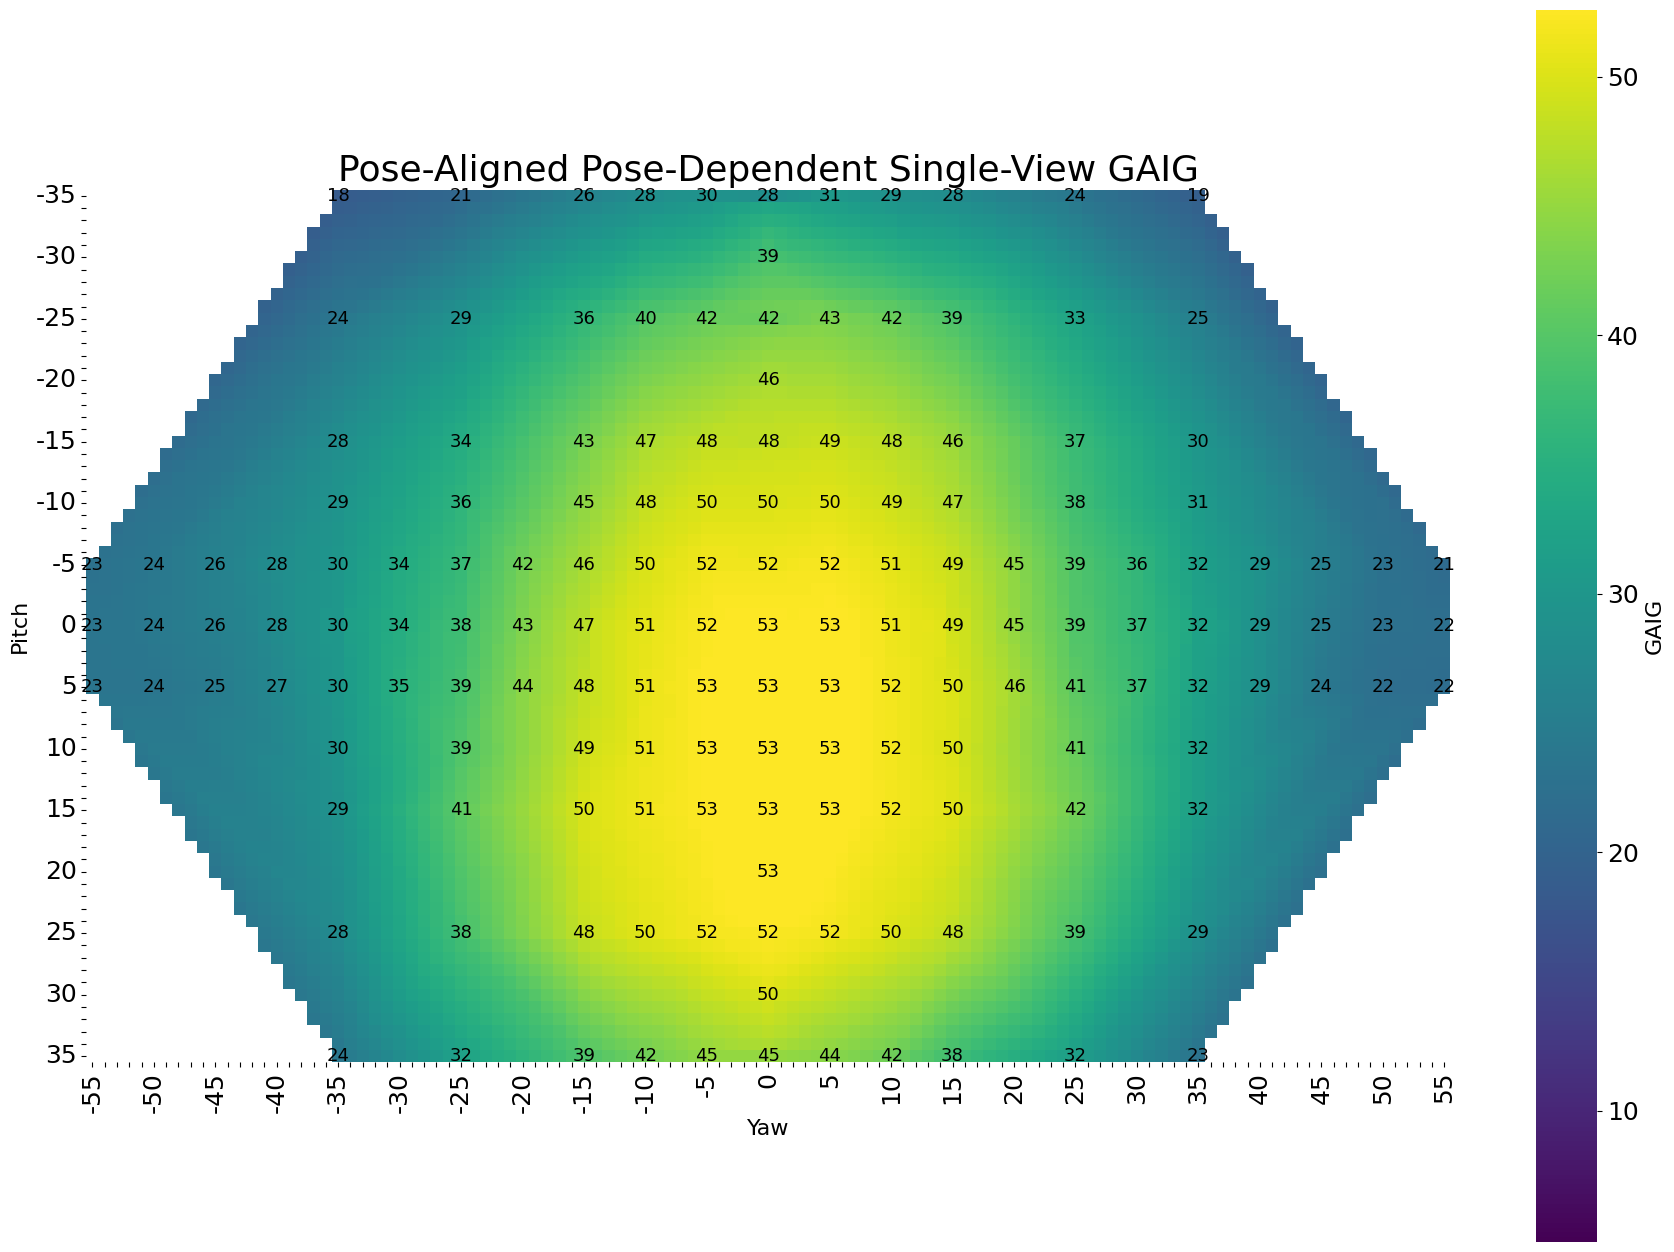

In [4]:
name="test_rgb_bff_crop305_emb-edgeface_xs"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_gaig, pitches, yaws, heatmap_min, heatmap_max = compute_gaig_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_gaig, pitches, yaws = compute_gaig_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name, vmin=heatmap_min, vmax=heatmap_max)

Loading classes:   0%|          | 0/1041 [00:00<?, ?it/s]

Loading classes: 100%|██████████| 1041/1041 [02:47<00:00,  6.21it/s]


Loading cached heatmap: test_rgb_bff_crop305_emb-adaface_webface12m_gaig_heatmap_cache.npz
Saved heatmap cache: test_rgb_bff_crop305_emb-adaface_webface12m_gaig_heatmap_cache.npz


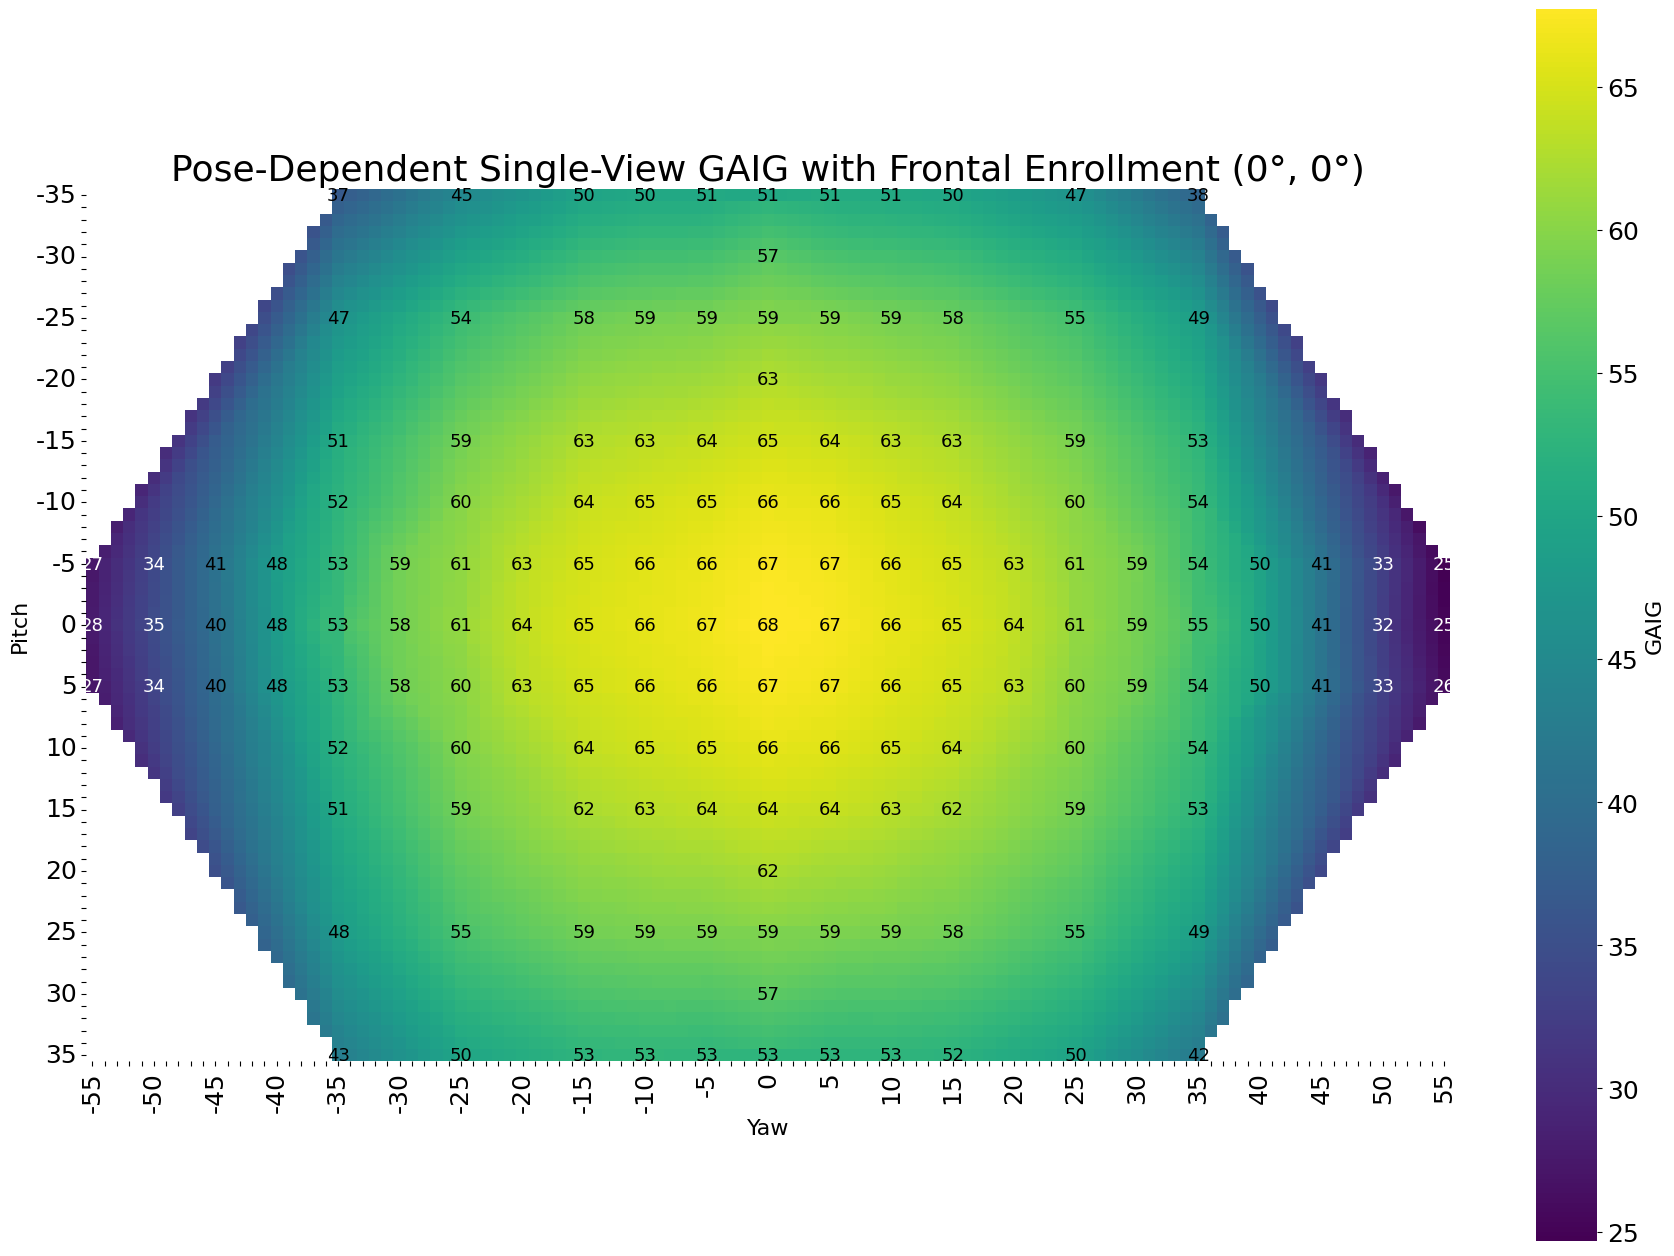

Processing Queries: 100%|██████████| 18745/18745 [16:06<00:00, 19.39it/s]


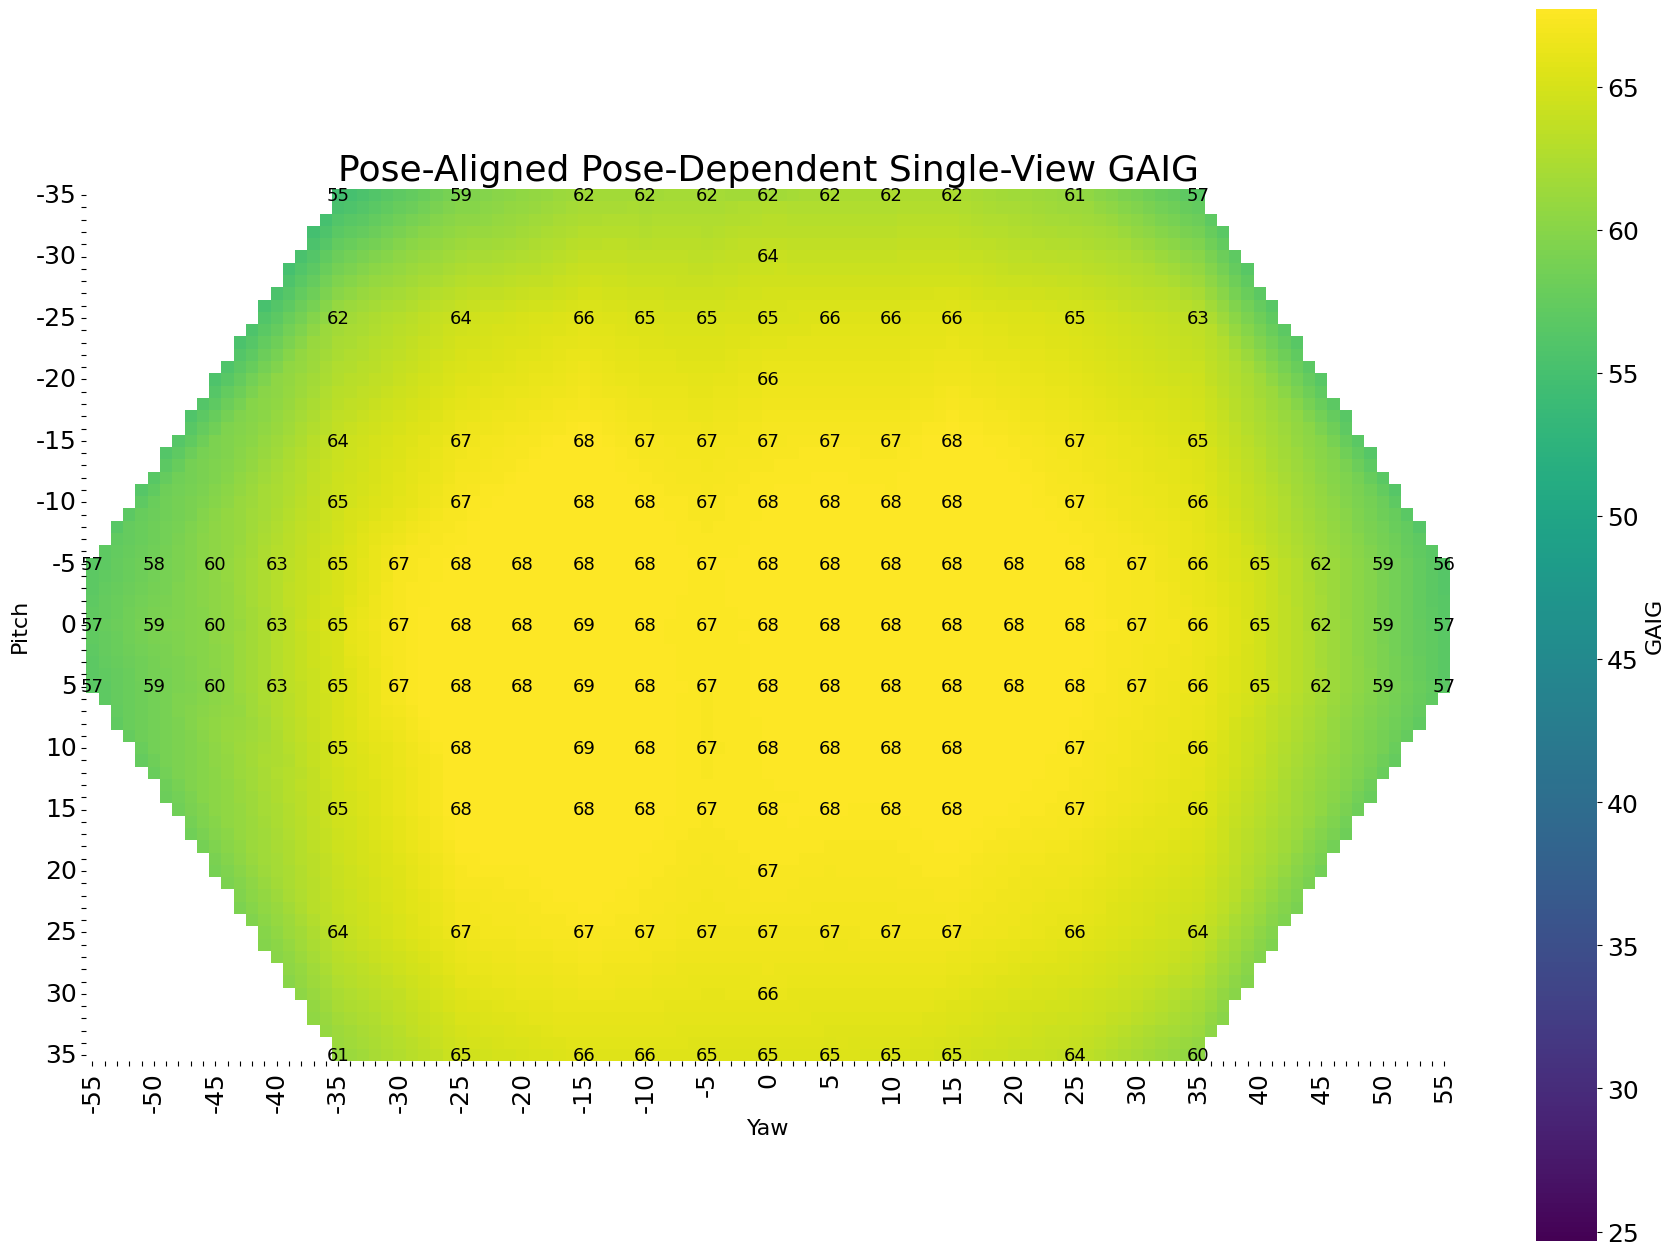

In [5]:
name="test_rgb_bff_crop305_emb-adaface_webface12m"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_gaig, pitches, yaws, heatmap_min, heatmap_max = compute_gaig_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_gaig, pitches, yaws = compute_gaig_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name, vmin=heatmap_min, vmax=heatmap_max)

Loading classes: 100%|██████████| 1041/1041 [03:02<00:00,  5.71it/s]


Loading cached heatmap: test_rgb_bff_crop305_emb-ms1mv3_r18_gaig_heatmap_cache.npz
Saved heatmap cache: test_rgb_bff_crop305_emb-ms1mv3_r18_gaig_heatmap_cache.npz


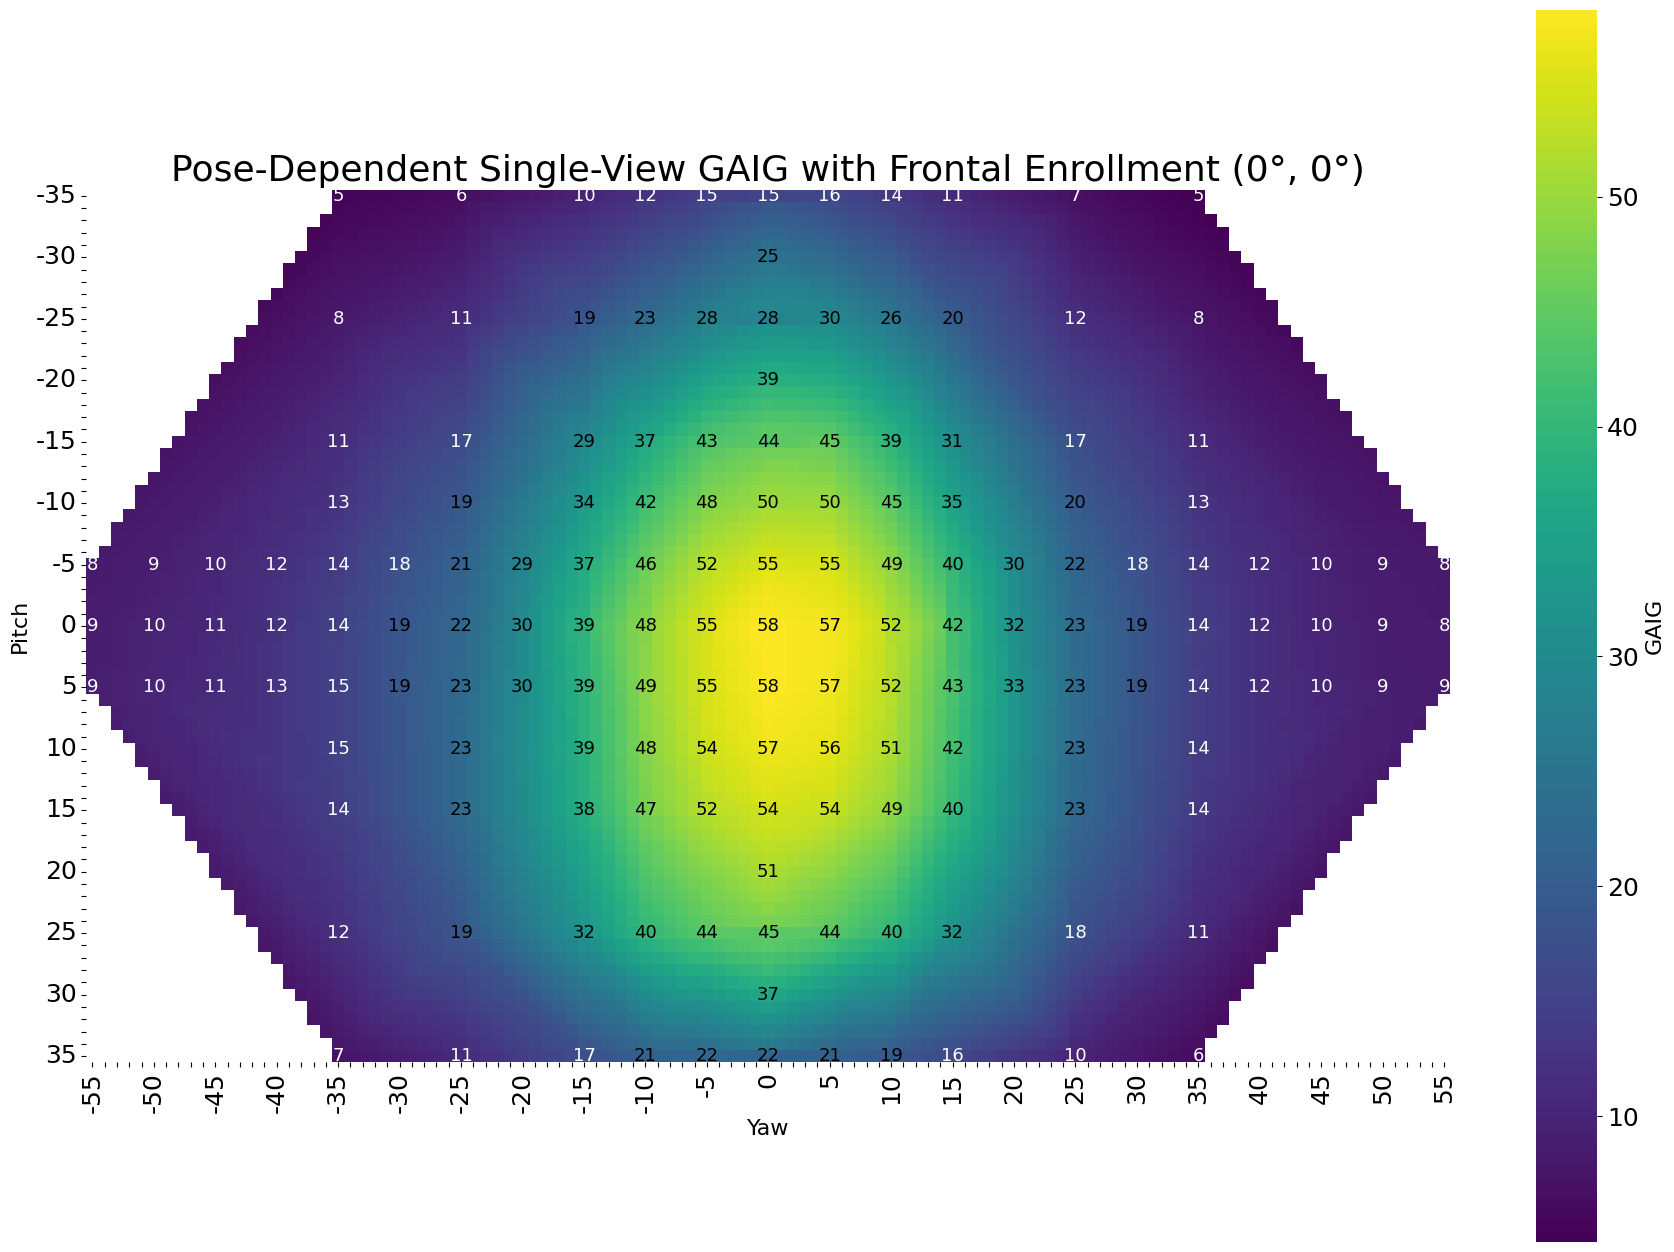

Processing Queries: 100%|██████████| 18745/18745 [17:29<00:00, 17.86it/s]


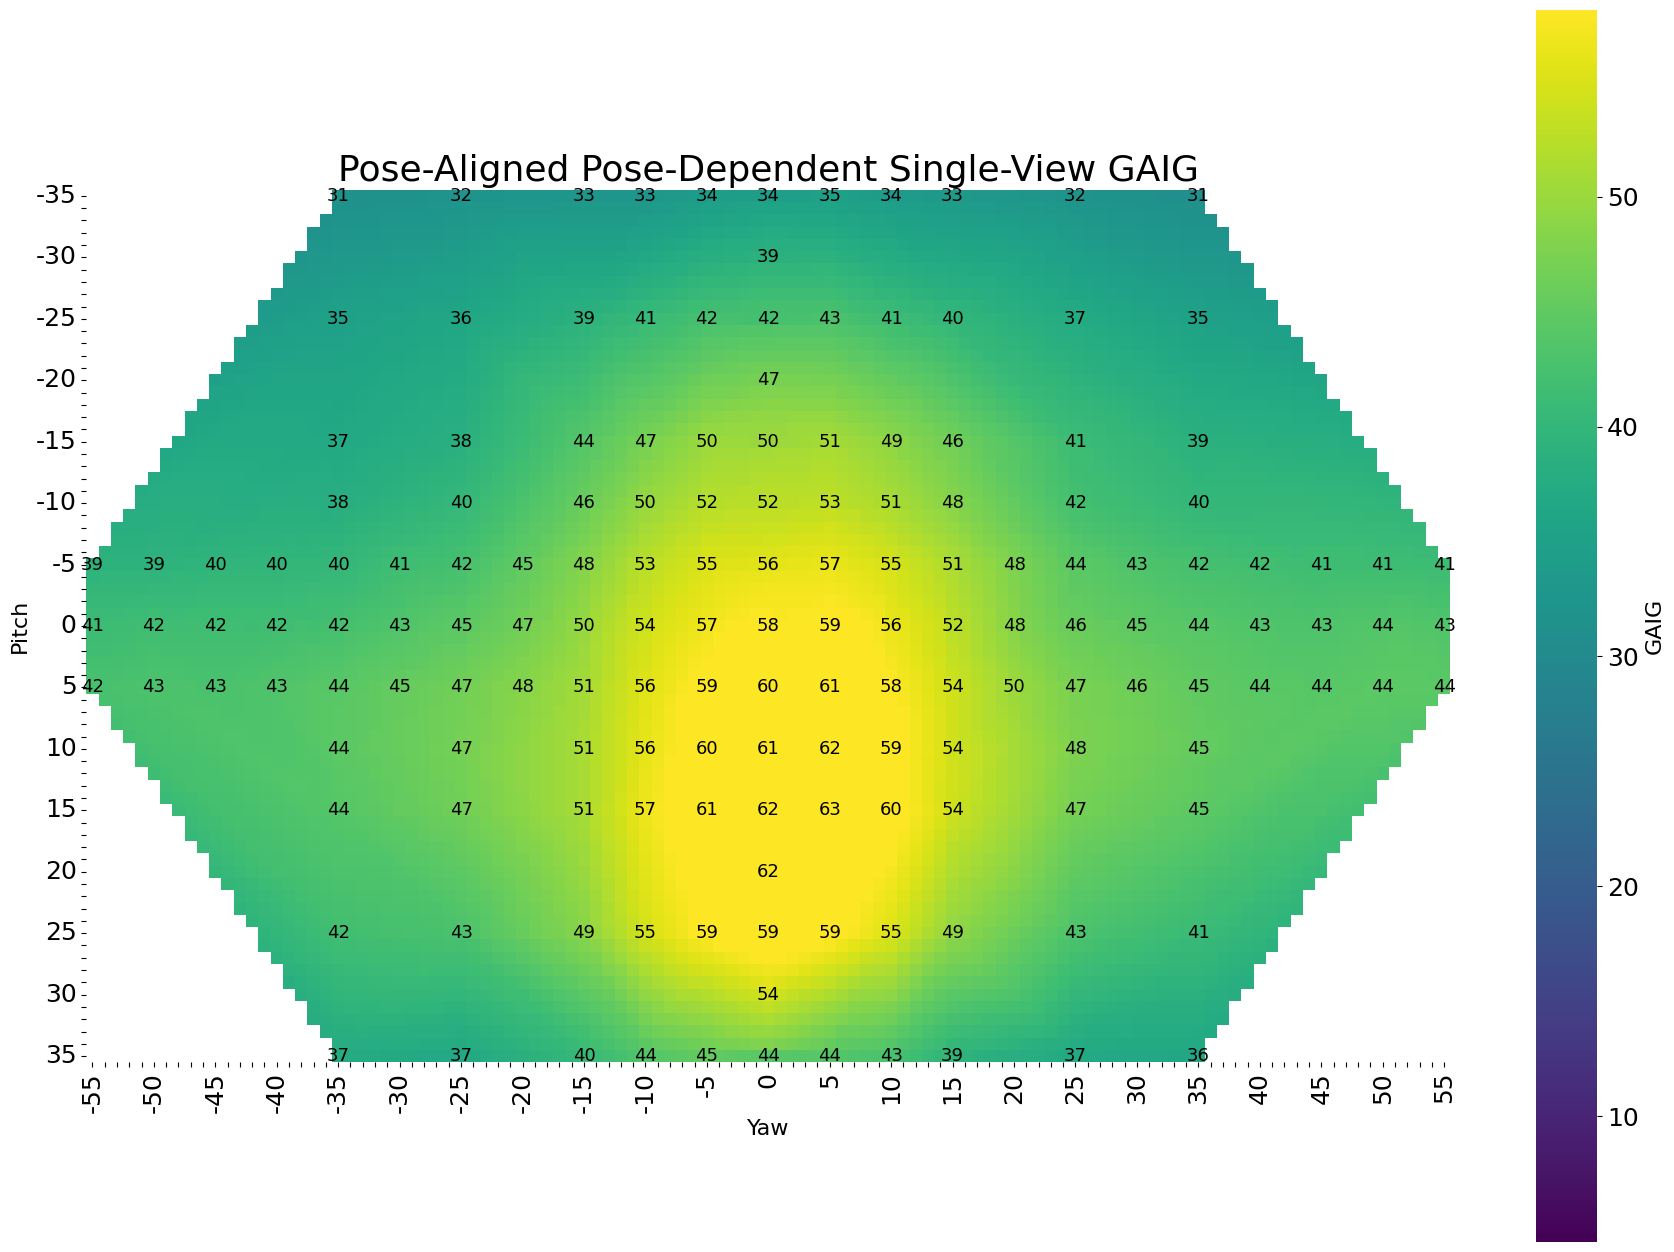

In [7]:
name="test_rgb_bff_crop305_emb-ms1mv3_r18"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_gaig, pitches, yaws, heatmap_min, heatmap_max = compute_gaig_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_gaig, pitches, yaws = compute_gaig_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name, vmin=heatmap_min, vmax=heatmap_max)

Processing Queries: 100%|██████████| 18745/18745 [12:27<00:00, 25.09it/s]


Saved heatmap cache: test_rgb_bff_crop305_emb-ms1mv3_r50_gaig_heatmap_cache.npz


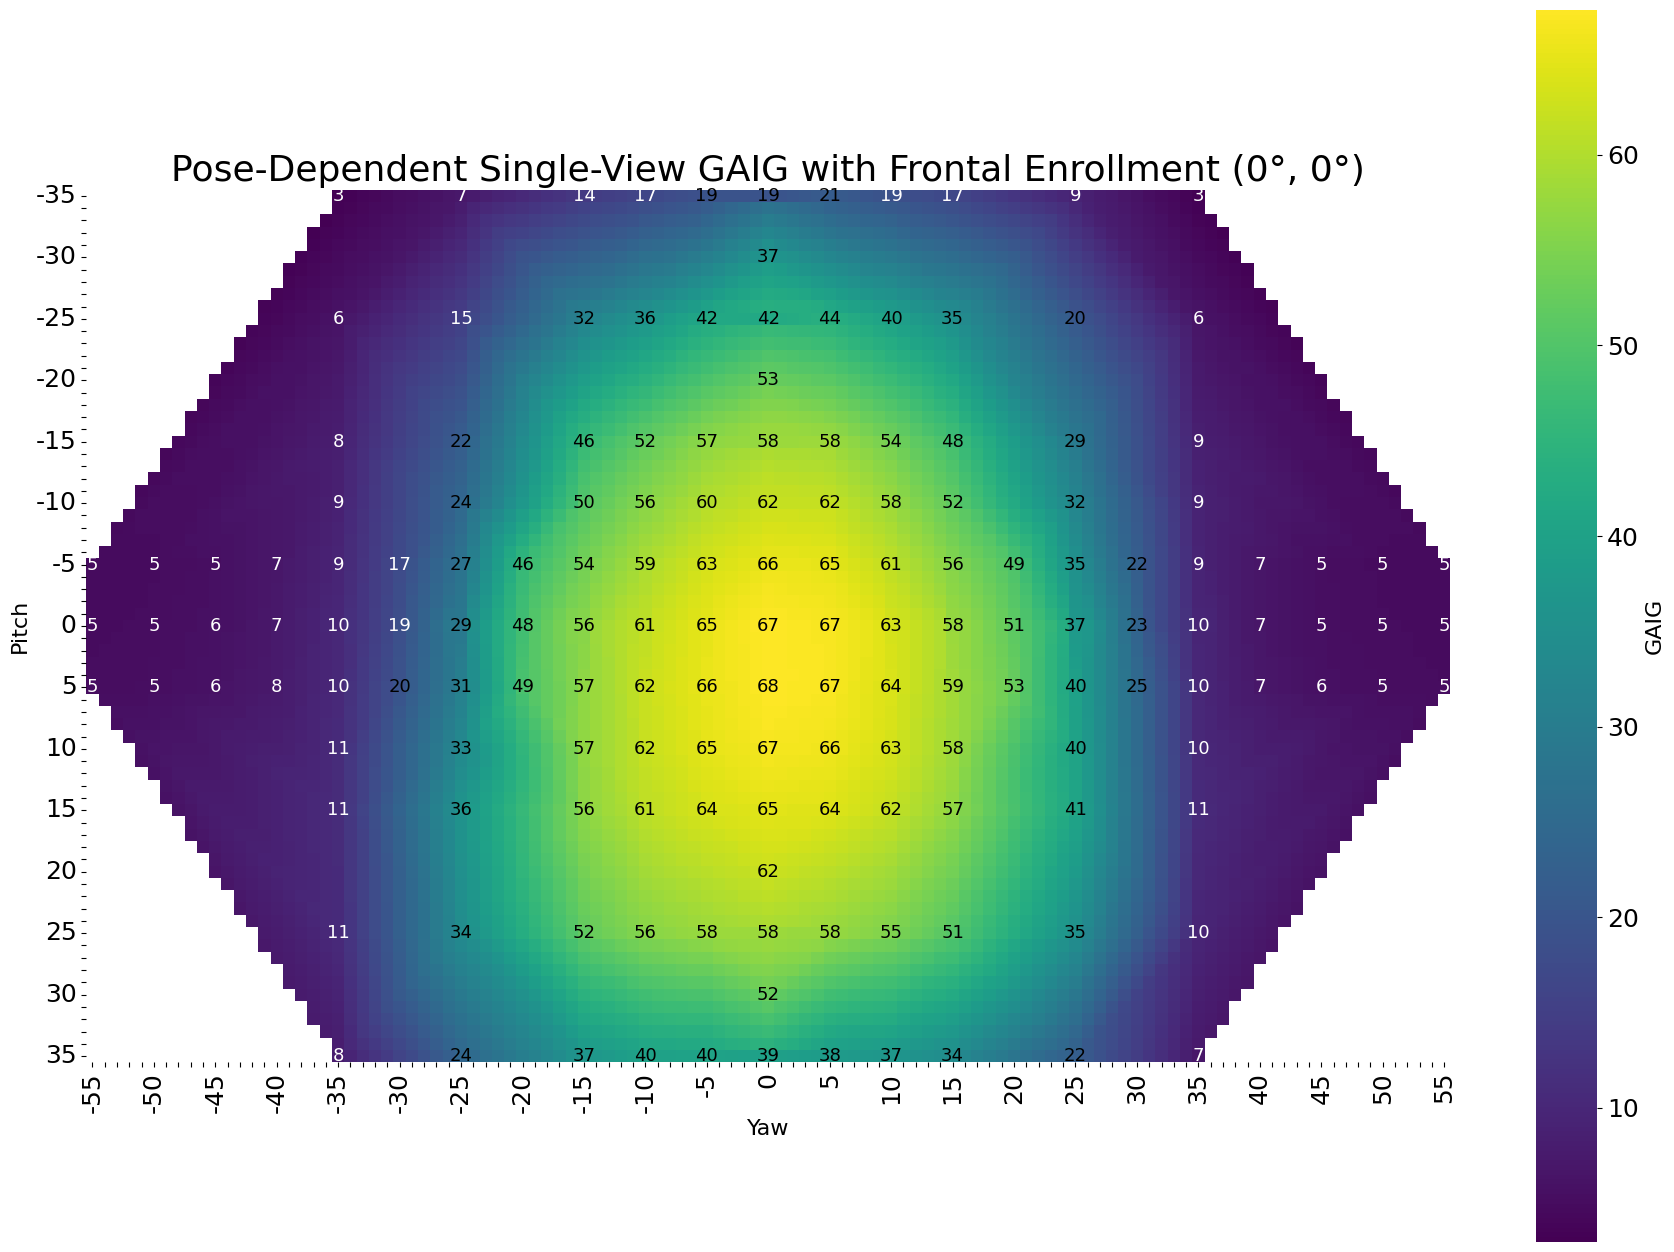

Processing Queries: 100%|██████████| 18745/18745 [17:24<00:00, 17.94it/s]


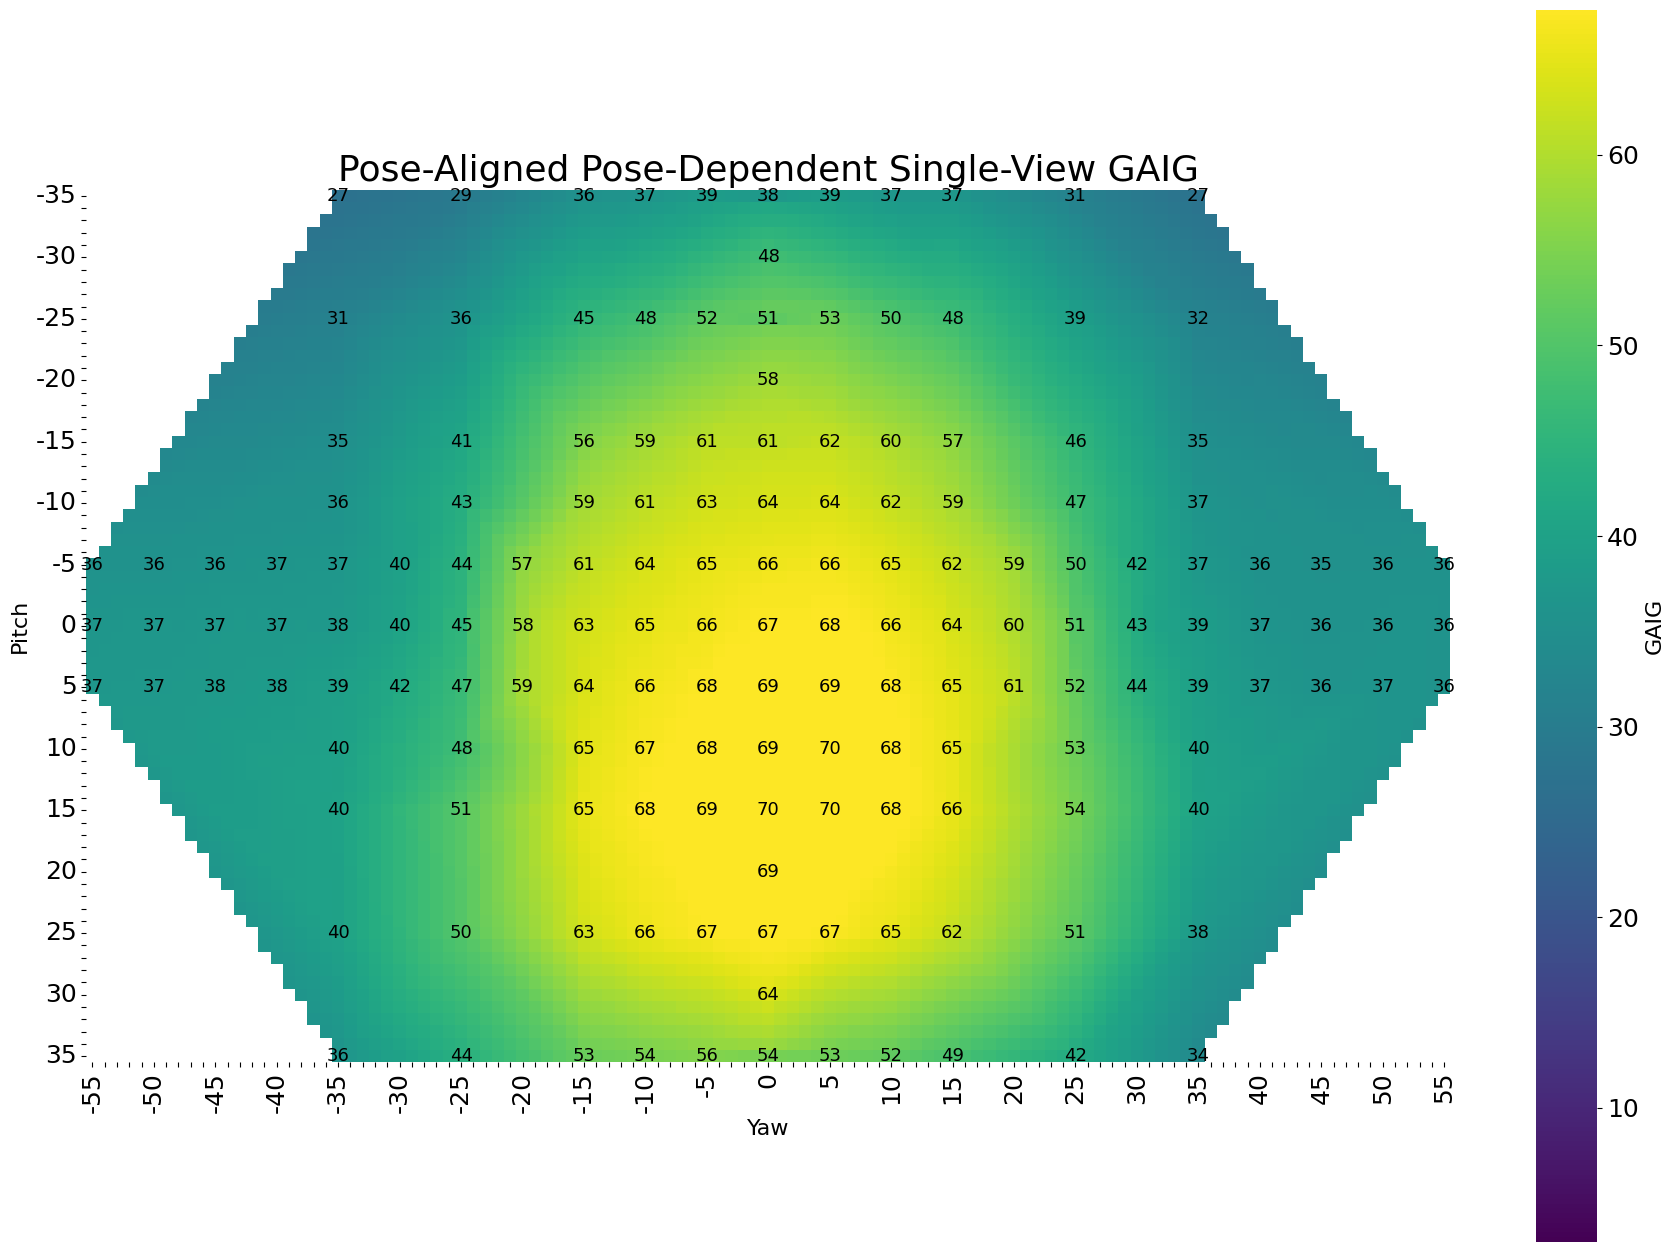

In [8]:
name="test_rgb_bff_crop305_emb-ms1mv3_r50"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_gaig, pitches, yaws, heatmap_min, heatmap_max = compute_gaig_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_gaig, pitches, yaws = compute_gaig_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name, vmin=heatmap_min, vmax=heatmap_max)

Processing Queries: 100%|██████████| 18745/18745 [11:23<00:00, 27.42it/s]


Saved heatmap cache: test_rgb_bff_crop305_emb-ms1mv3_r100_gaig_heatmap_cache.npz


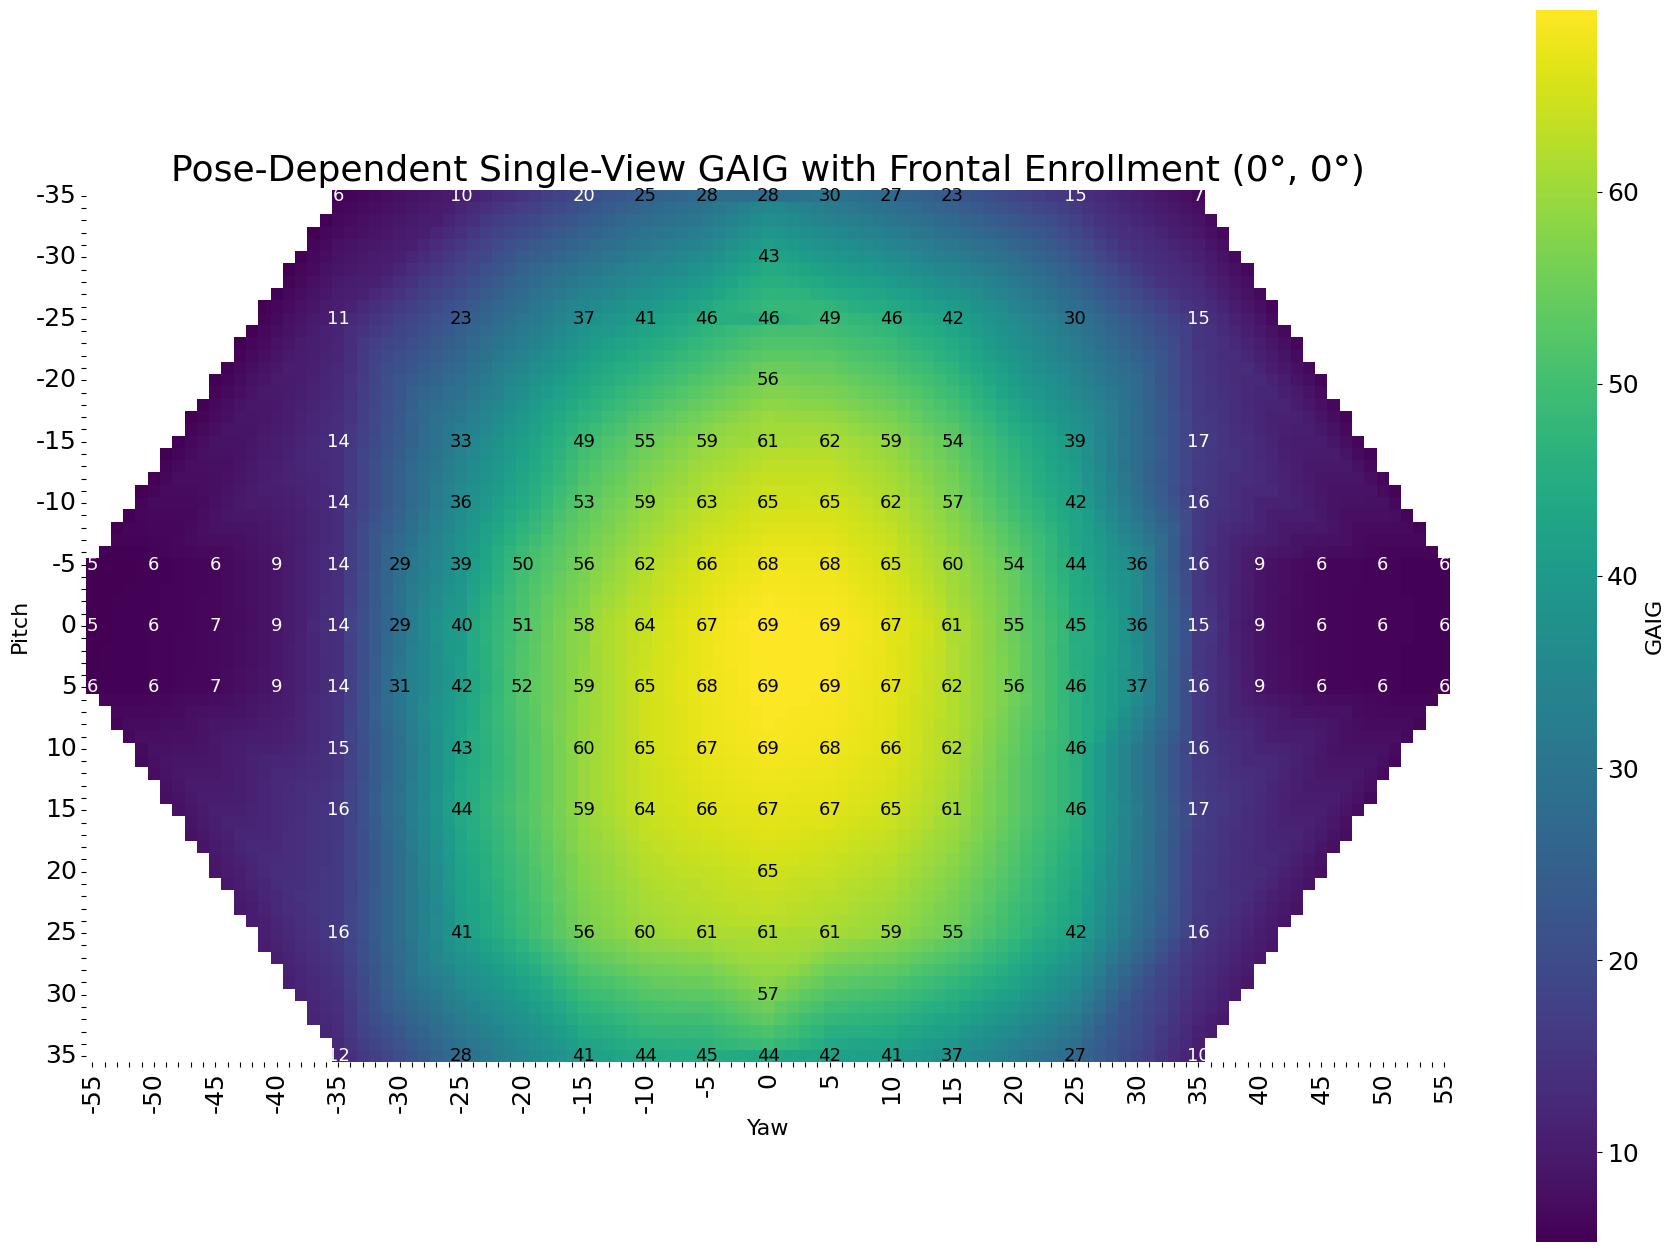

Processing Queries: 100%|██████████| 18745/18745 [15:17<00:00, 20.43it/s]


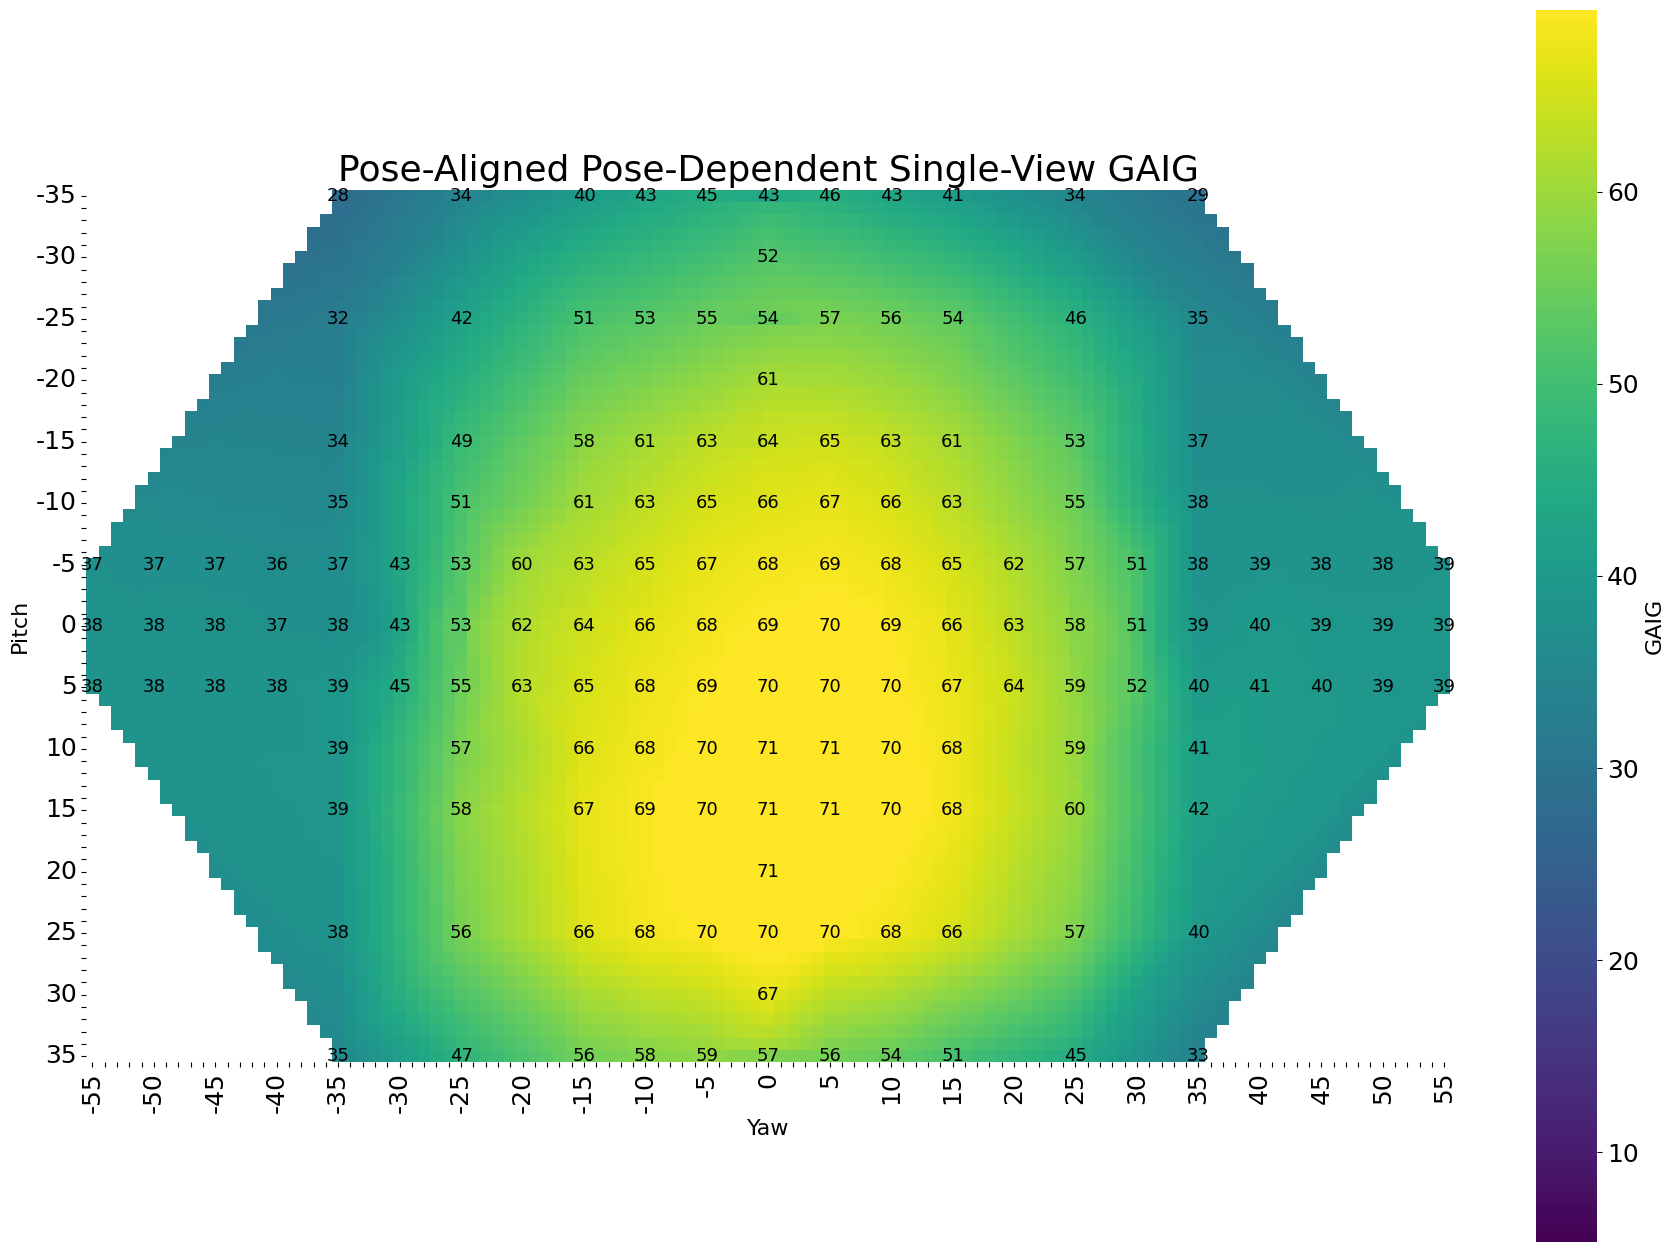

In [9]:
name="test_rgb_bff_crop305_emb-ms1mv3_r100"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_gaig, pitches, yaws, heatmap_min, heatmap_max = compute_gaig_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_gaig, pitches, yaws = compute_gaig_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name, vmin=heatmap_min, vmax=heatmap_max)

Processing Queries: 100%|██████████| 18745/18745 [11:50<00:00, 26.39it/s]


Saved heatmap cache: test_rgb_bff_crop305_emb-glint_r18_gaig_heatmap_cache.npz


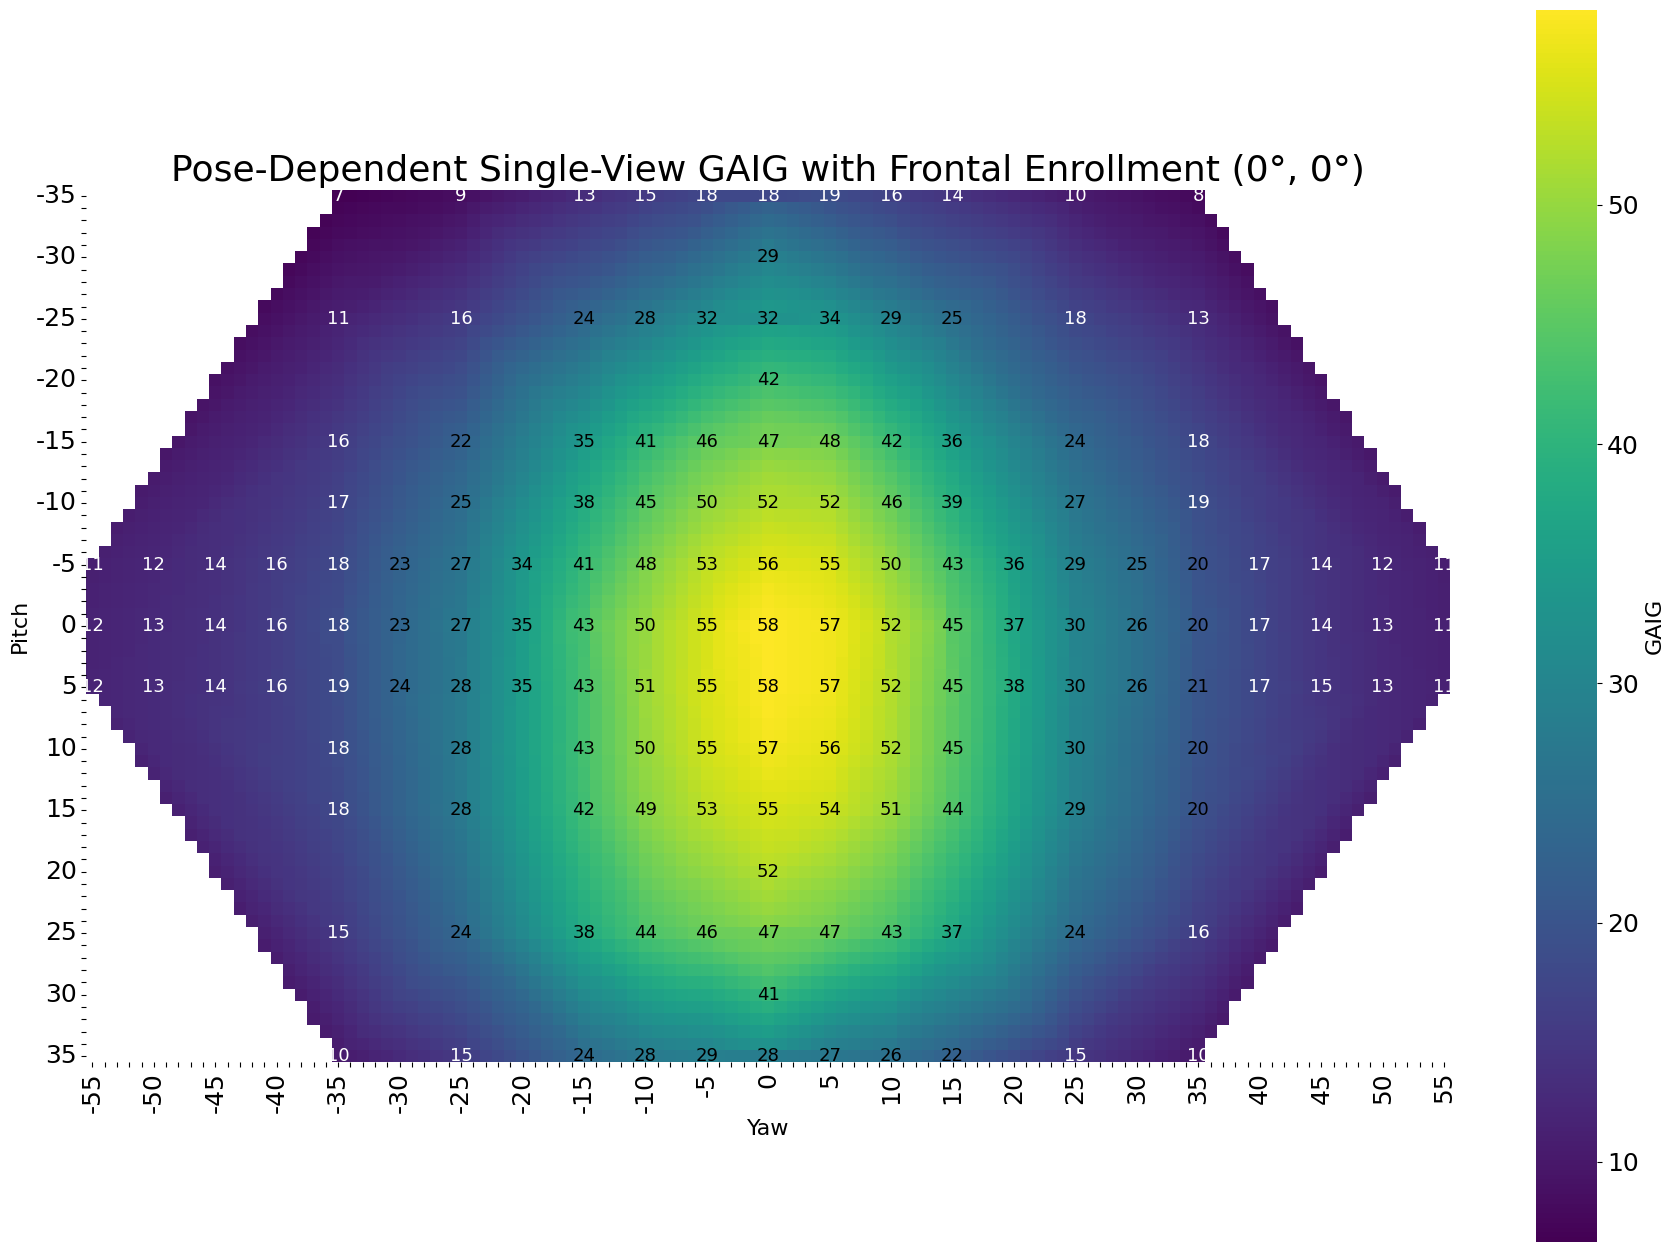

Processing Queries: 100%|██████████| 18745/18745 [15:14<00:00, 20.51it/s]


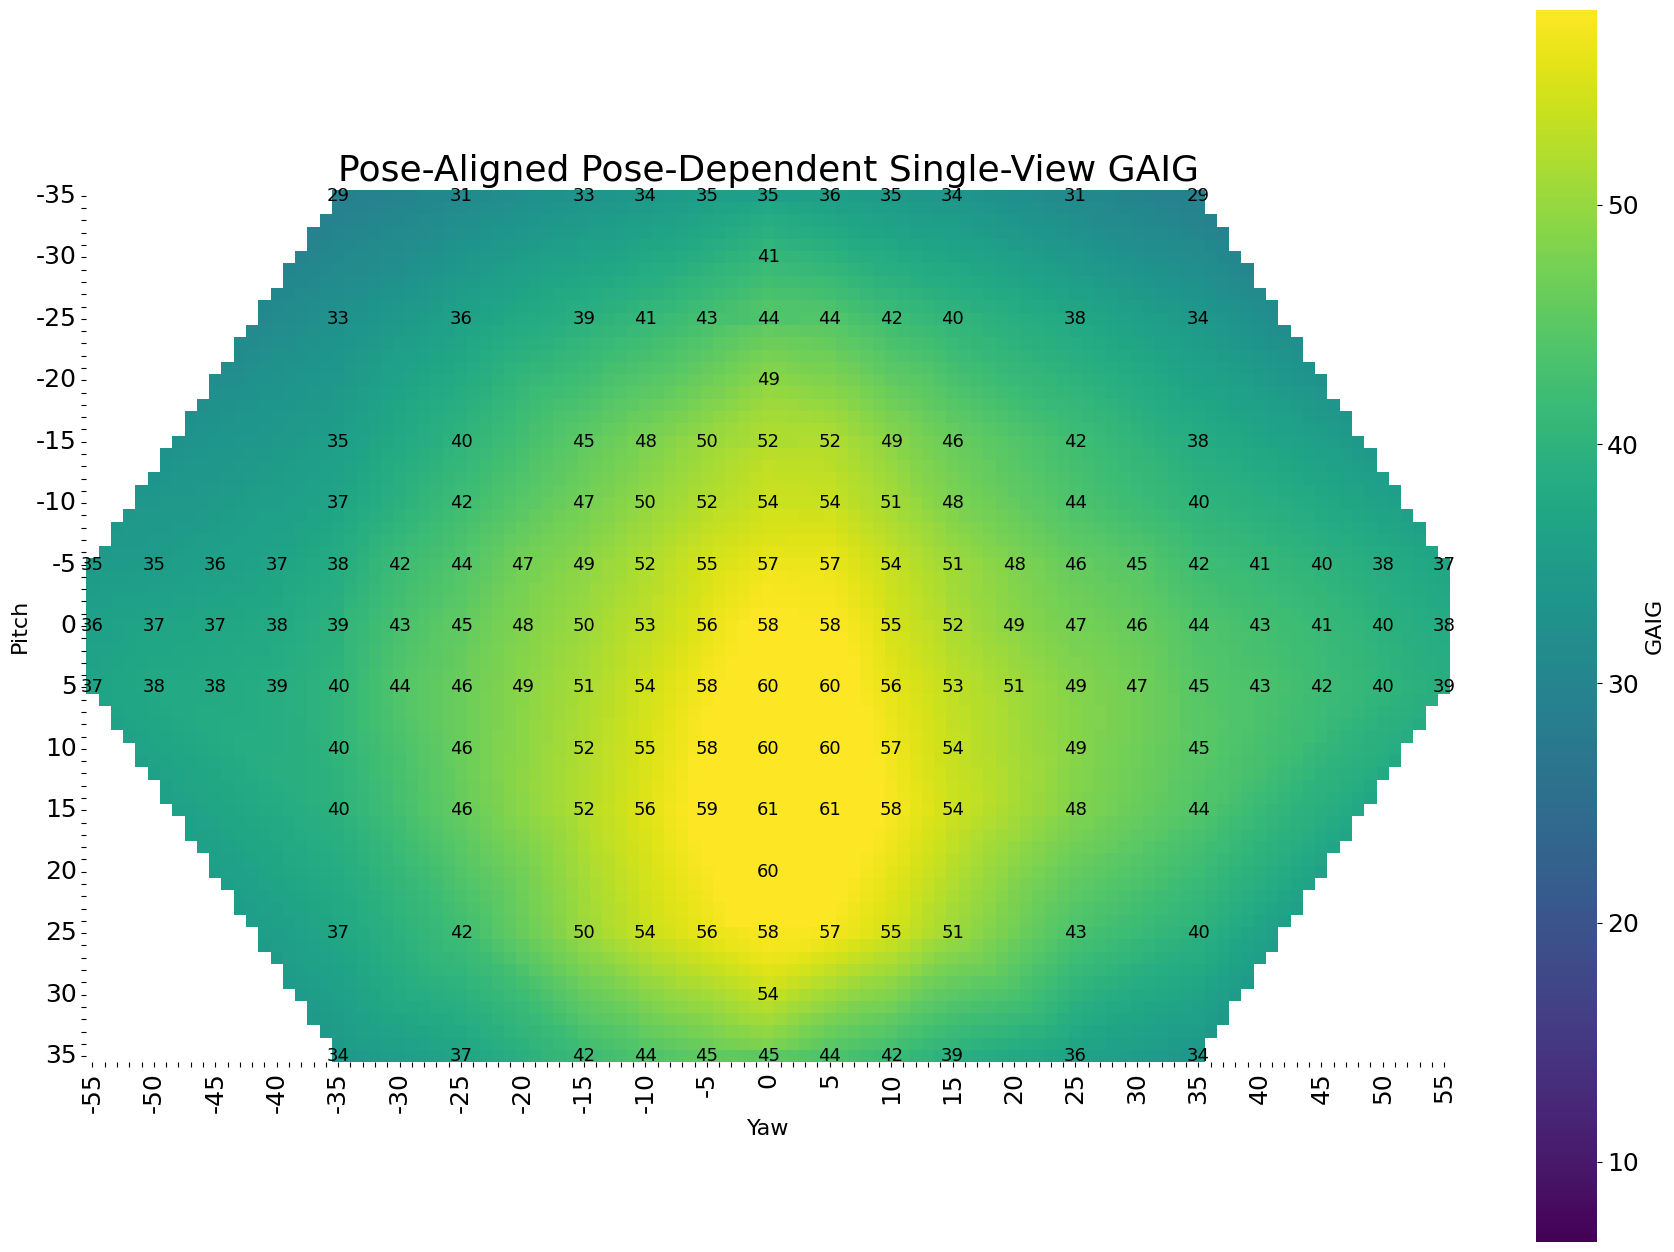

In [10]:
name="test_rgb_bff_crop305_emb-glint_r18"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_gaig, pitches, yaws, heatmap_min, heatmap_max = compute_gaig_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_gaig, pitches, yaws = compute_gaig_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name, vmin=heatmap_min, vmax=heatmap_max)

Processing Queries: 100%|██████████| 18745/18745 [11:36<00:00, 26.90it/s]


Saved heatmap cache: test_rgb_bff_crop305_emb-glint_r100_gaig_heatmap_cache.npz


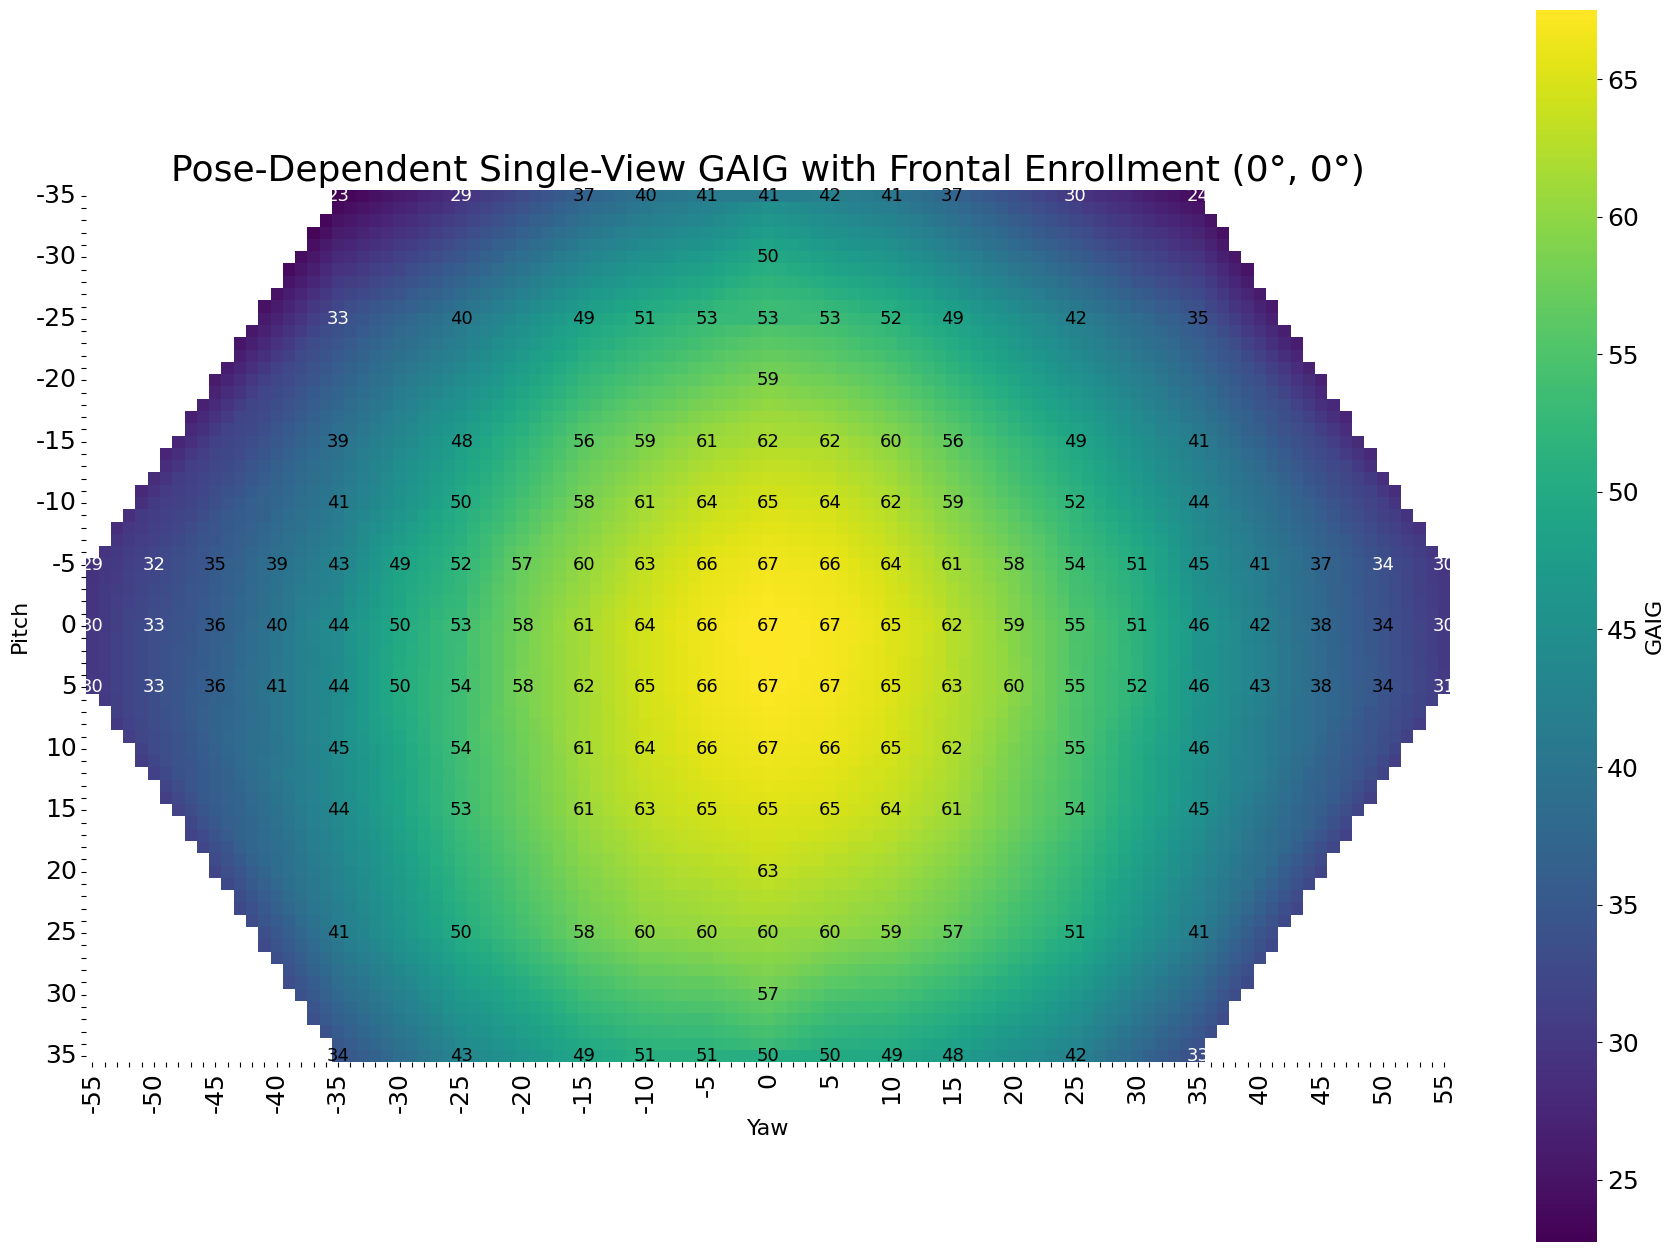

Processing Queries: 100%|██████████| 18745/18745 [14:24<00:00, 21.68it/s]


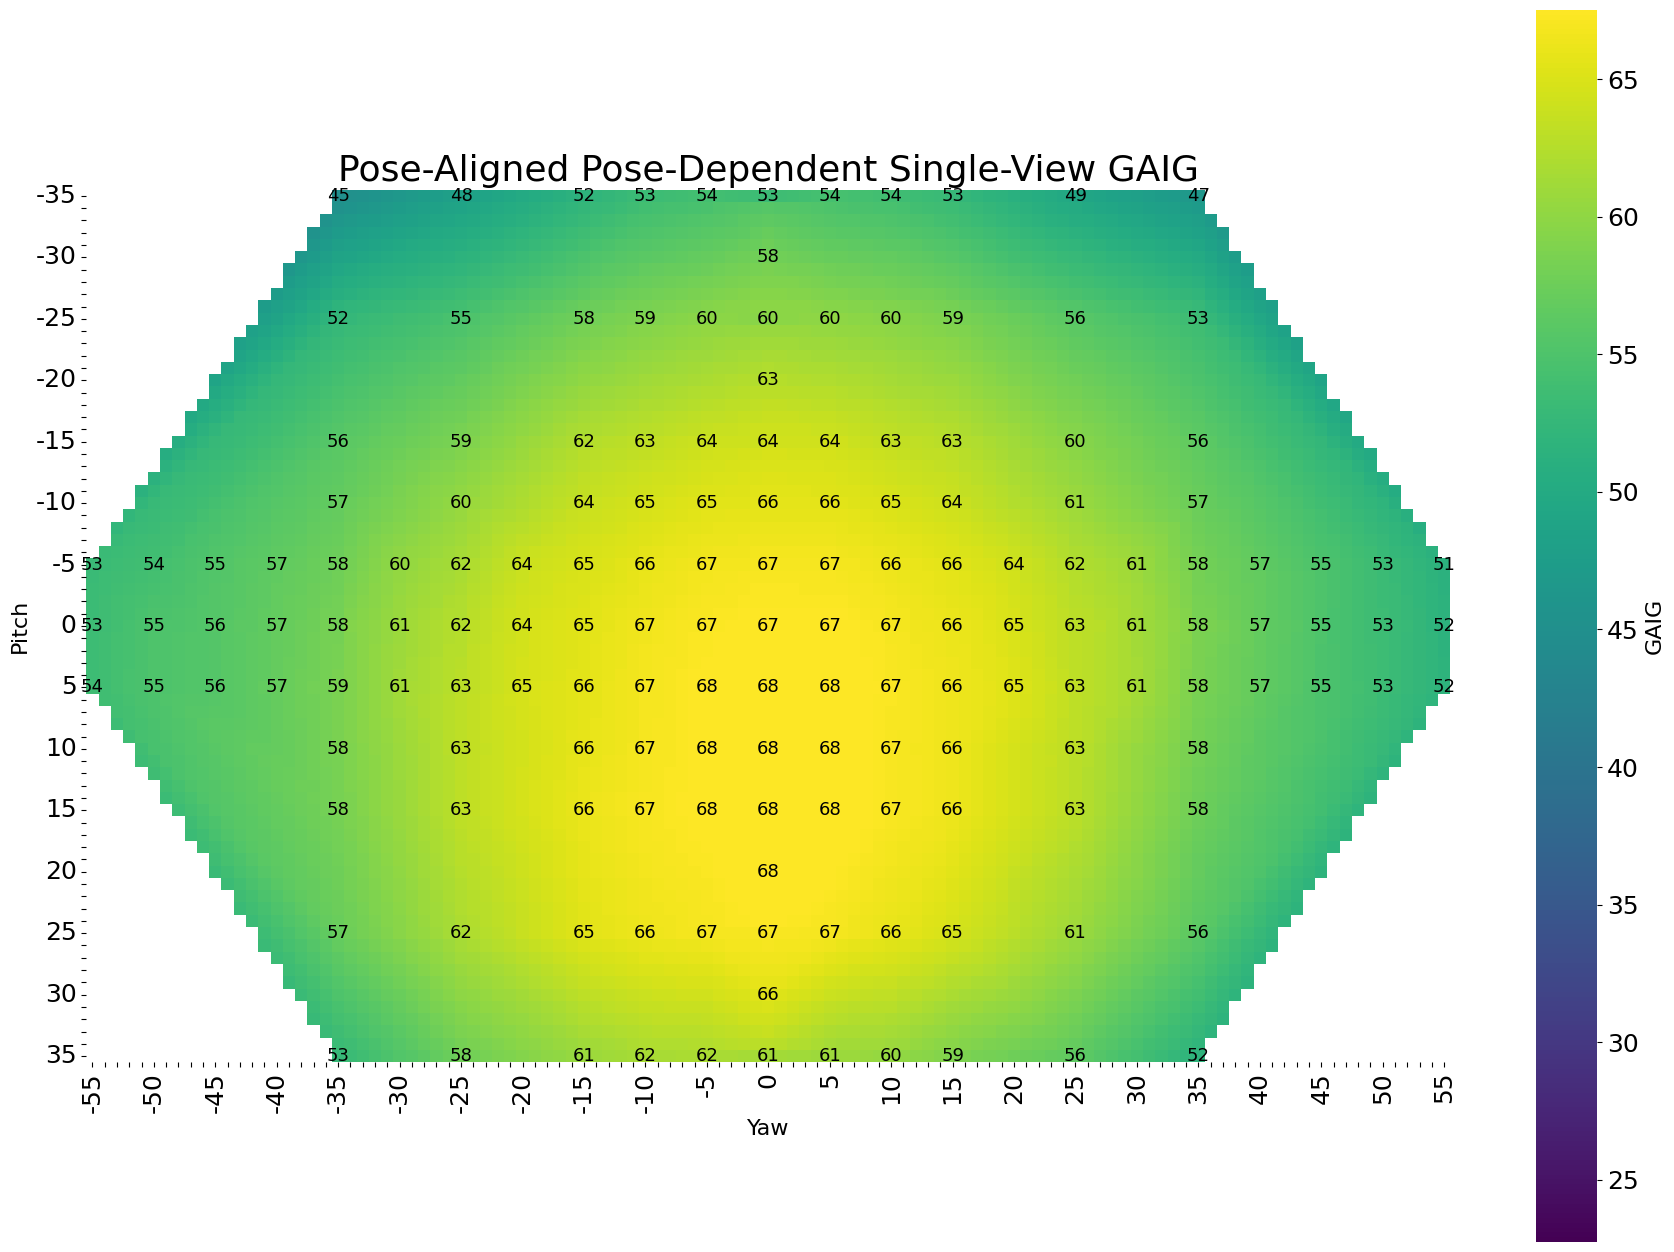

In [4]:
name="test_rgb_bff_crop305_emb-glint_r100"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_gaig, pitches, yaws, heatmap_min, heatmap_max = compute_gaig_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_gaig, pitches, yaws = compute_gaig_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name, vmin=heatmap_min, vmax=heatmap_max)

In [5]:
name="test_rgb_bff_crop261_emb-hyperface50k"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_gaig, pitches, yaws, heatmap_min, heatmap_max = compute_gaig_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_gaig, pitches, yaws = compute_gaig_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name, vmin=heatmap_min, vmax=heatmap_max)

FileNotFoundError: [WinError 3] Das System kann den angegebenen Pfad nicht finden: 'F:/Face/data/dataset16_emb/test_rgb_bff_crop261_emb-hyperface50k/enrolled/'

Processing Queries: 100%|██████████| 18745/18745 [11:37<00:00, 26.88it/s]


Saved heatmap cache: test_rgb_bff_crop305_emb-swinface_gaig_heatmap_cache.npz


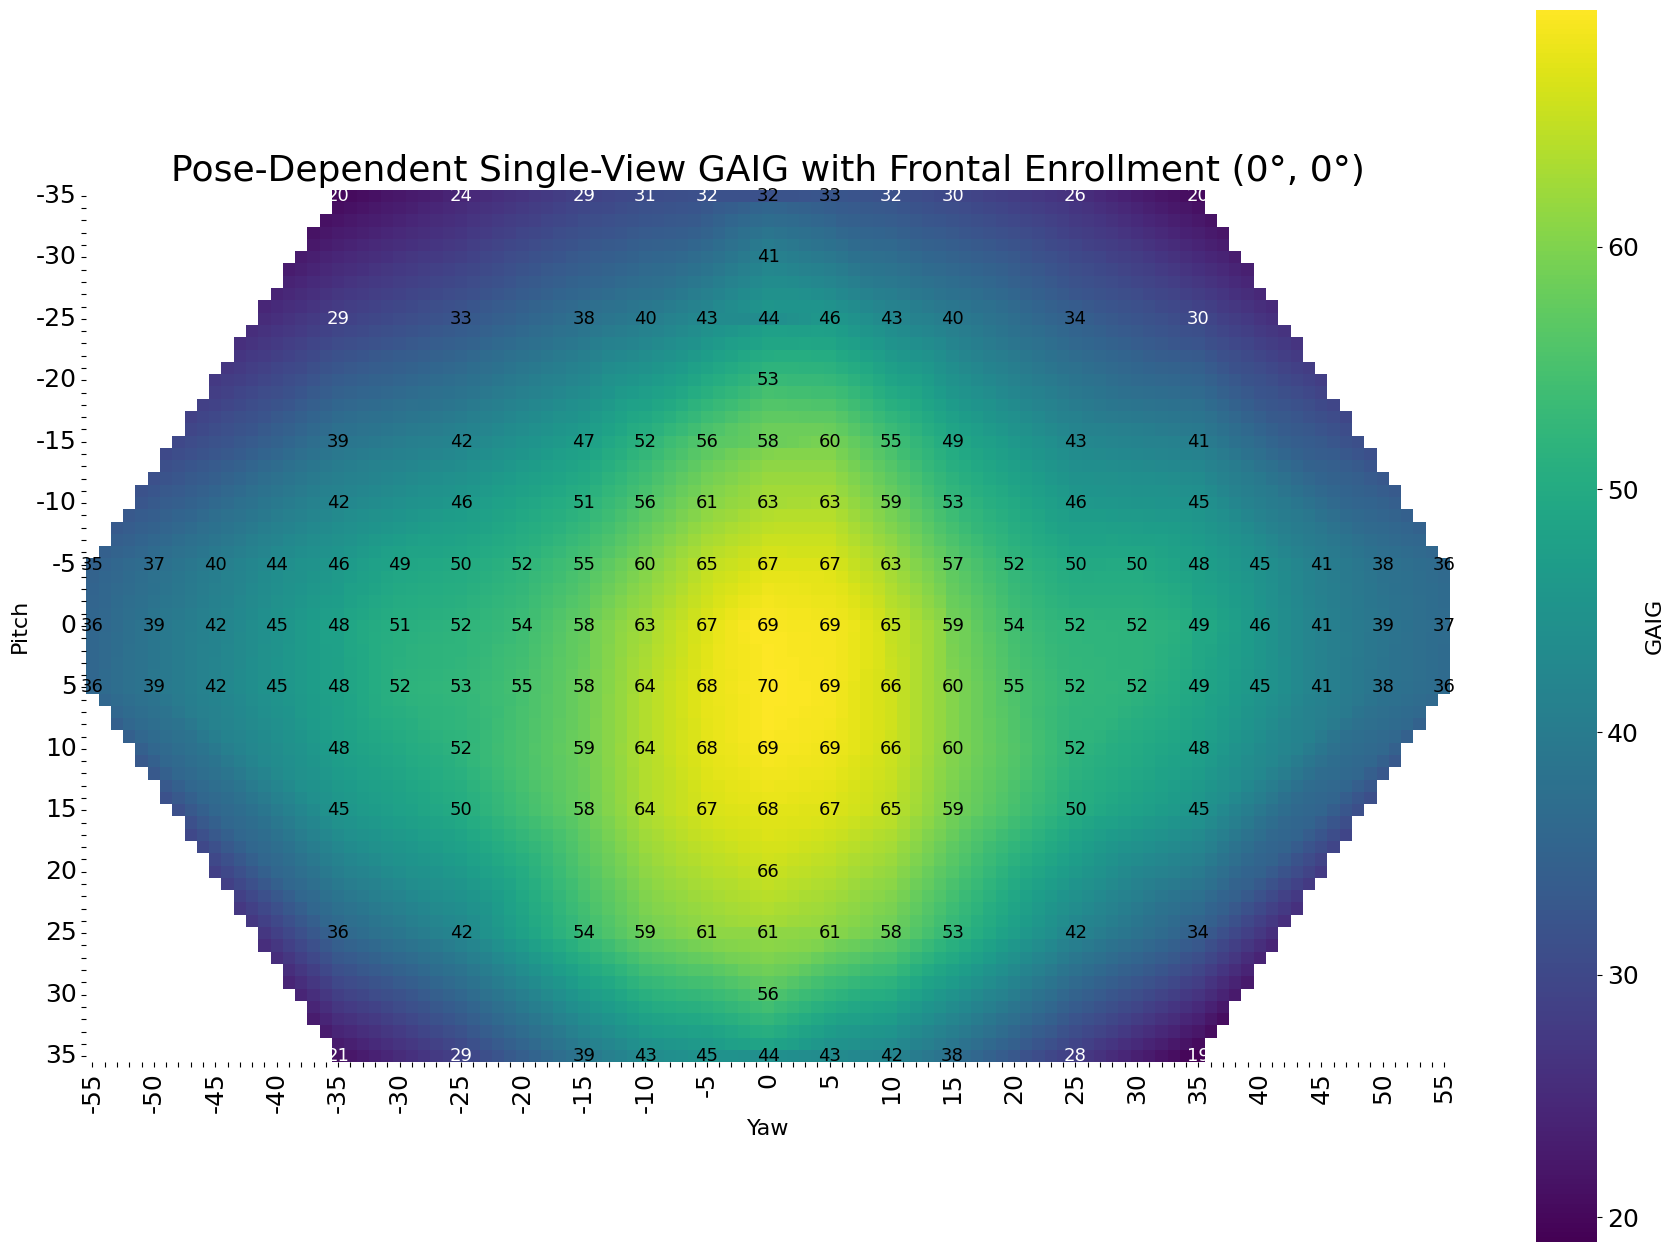

Processing Queries: 100%|██████████| 18745/18745 [14:03<00:00, 22.23it/s]


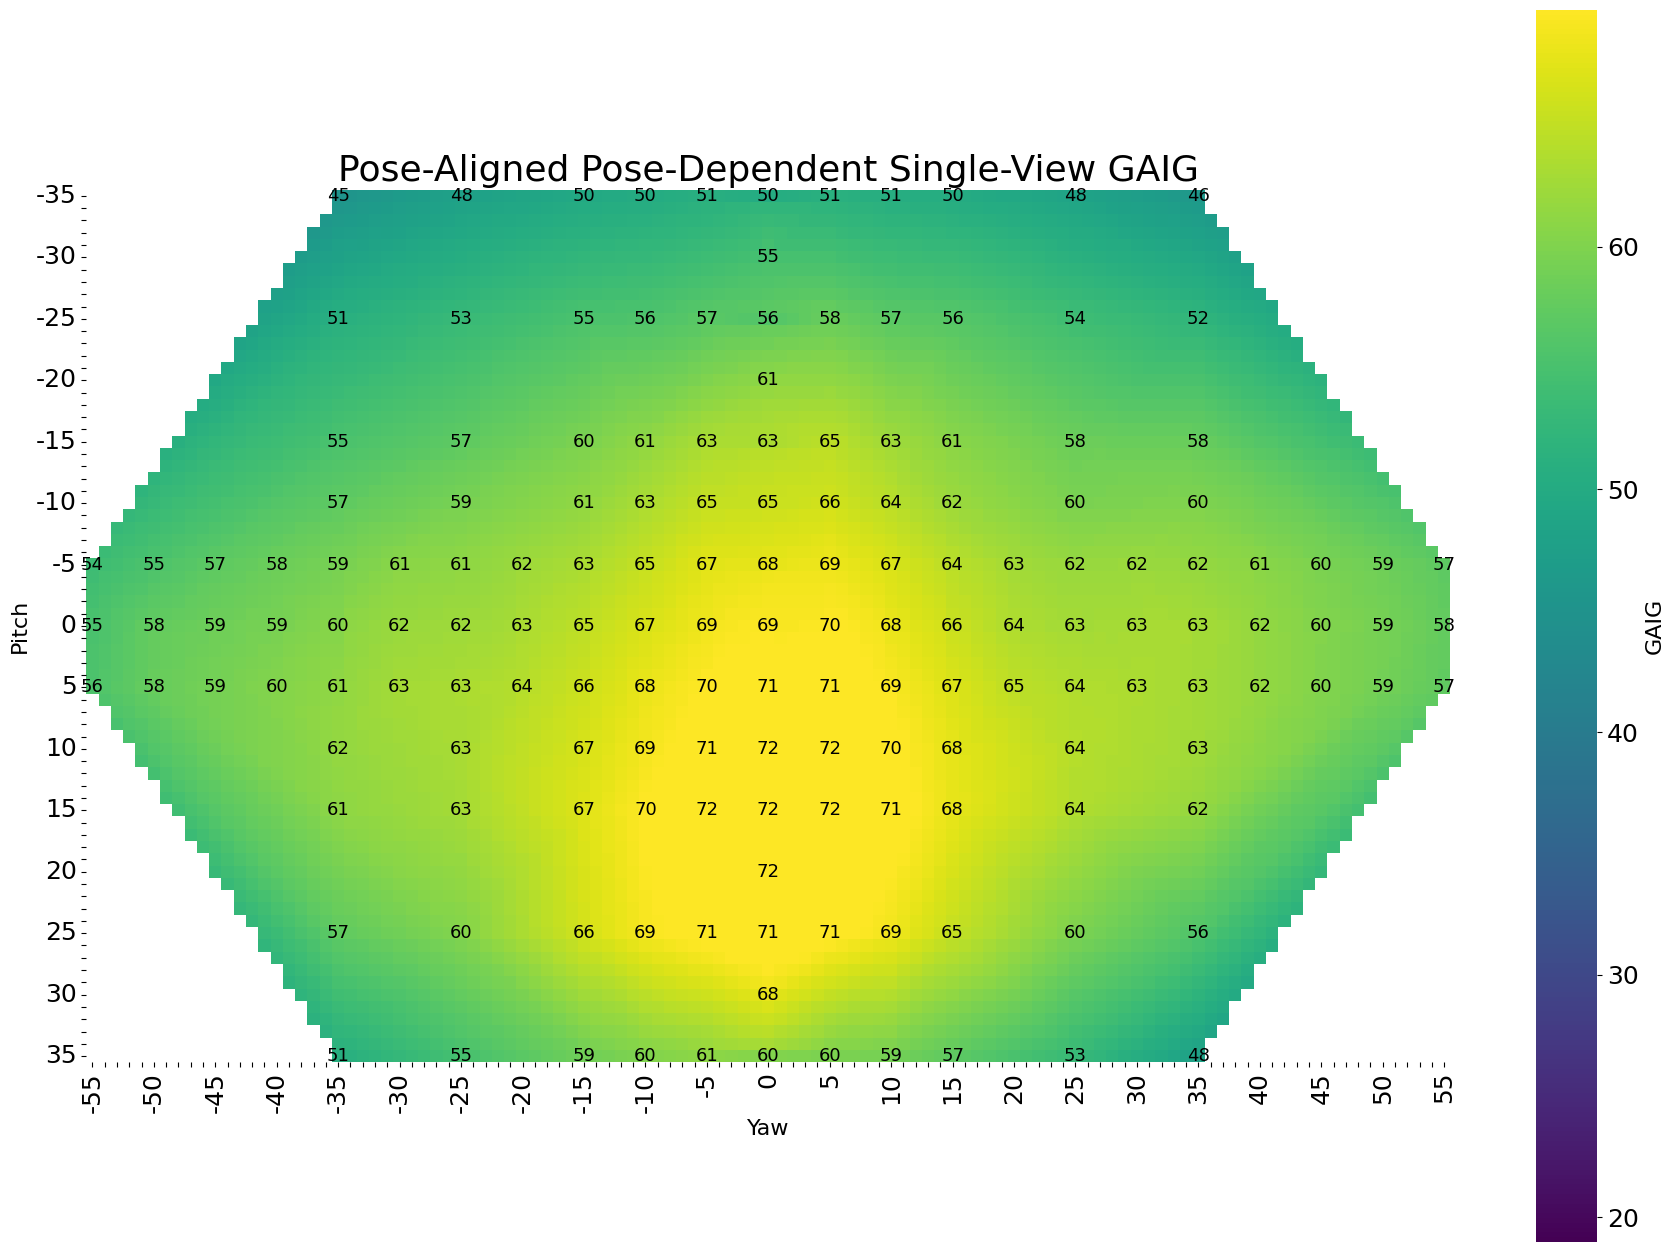

In [6]:
name="test_rgb_bff_crop305_emb-swinface"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_gaig, pitches, yaws, heatmap_min, heatmap_max = compute_gaig_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_gaig, pitches, yaws = compute_gaig_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name, vmin=heatmap_min, vmax=heatmap_max)

Processing Queries: 100%|██████████| 18745/18745 [10:40<00:00, 29.28it/s]


Saved heatmap cache: test_rgb_bff_crop305_emb-vit_gaig_heatmap_cache.npz


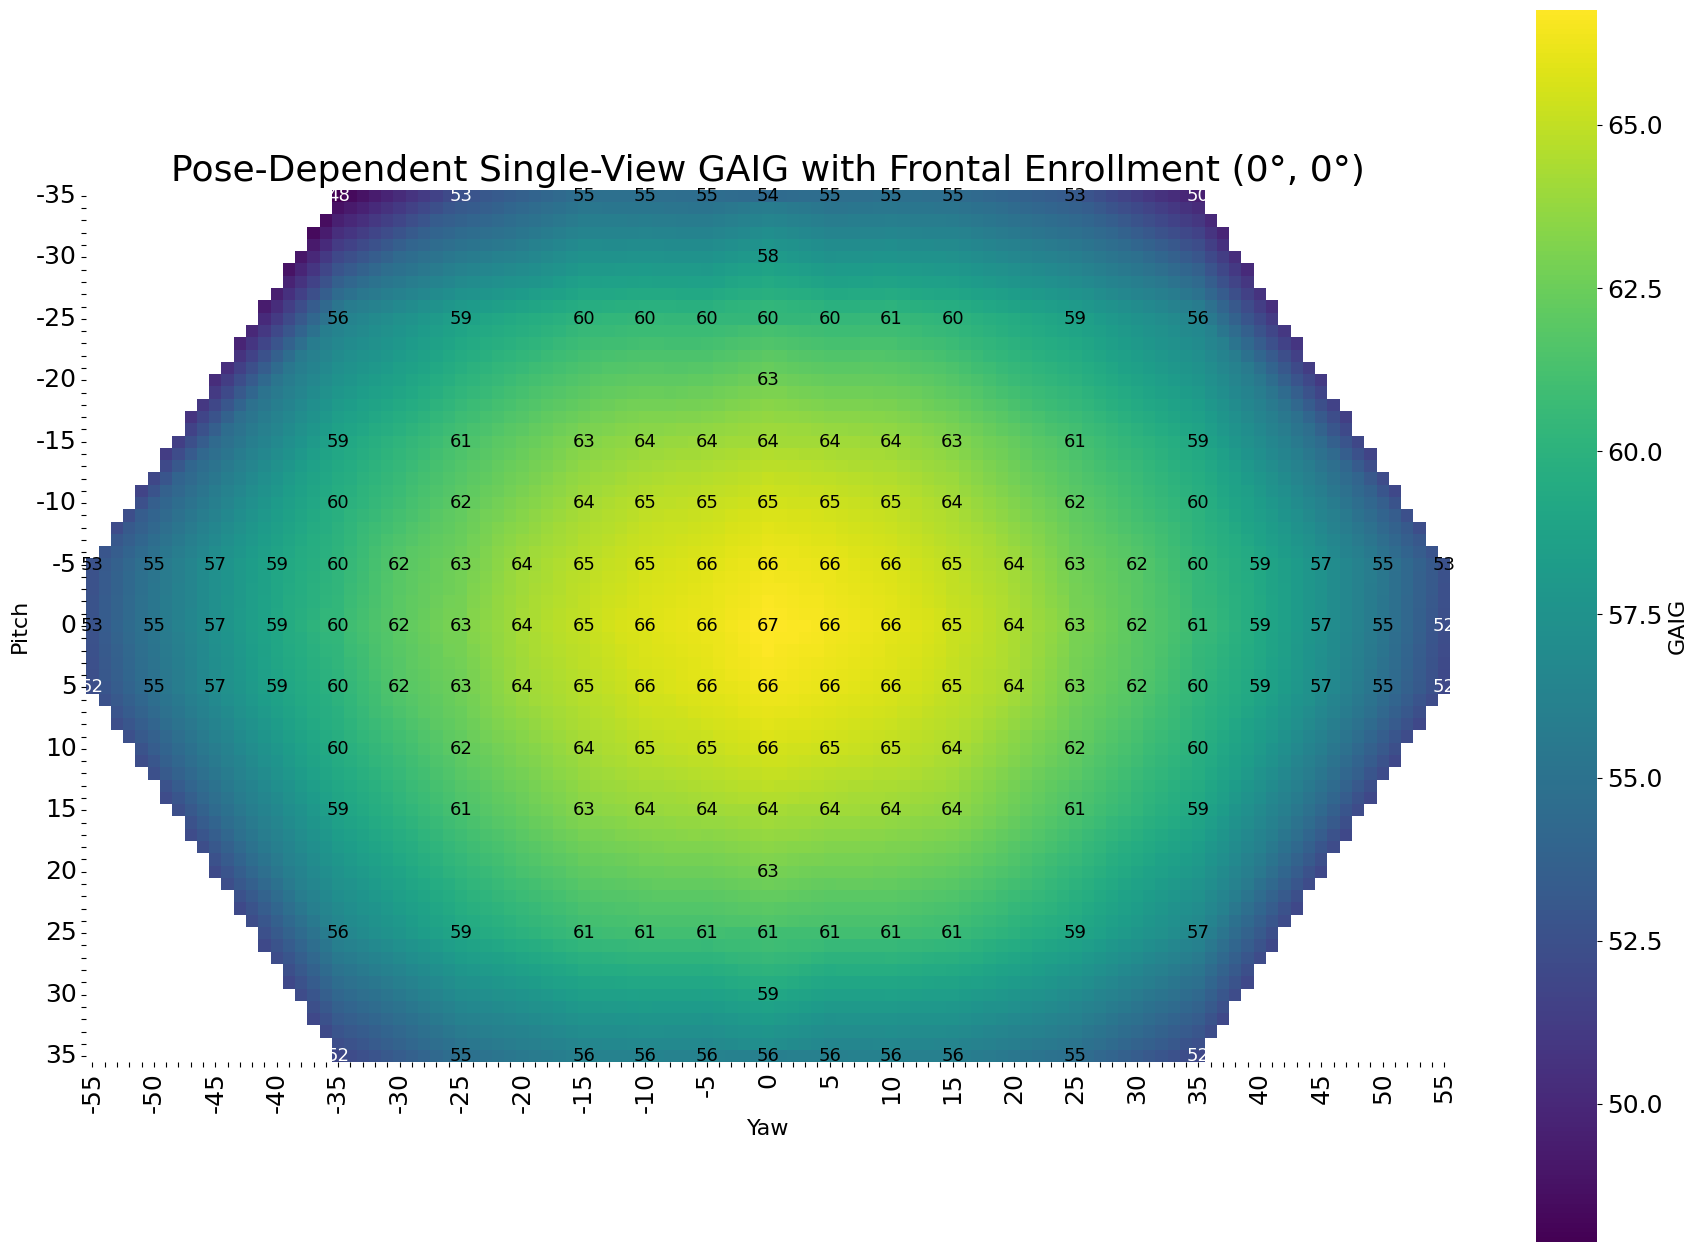

Processing Queries: 100%|██████████| 18745/18745 [13:02<00:00, 23.95it/s]


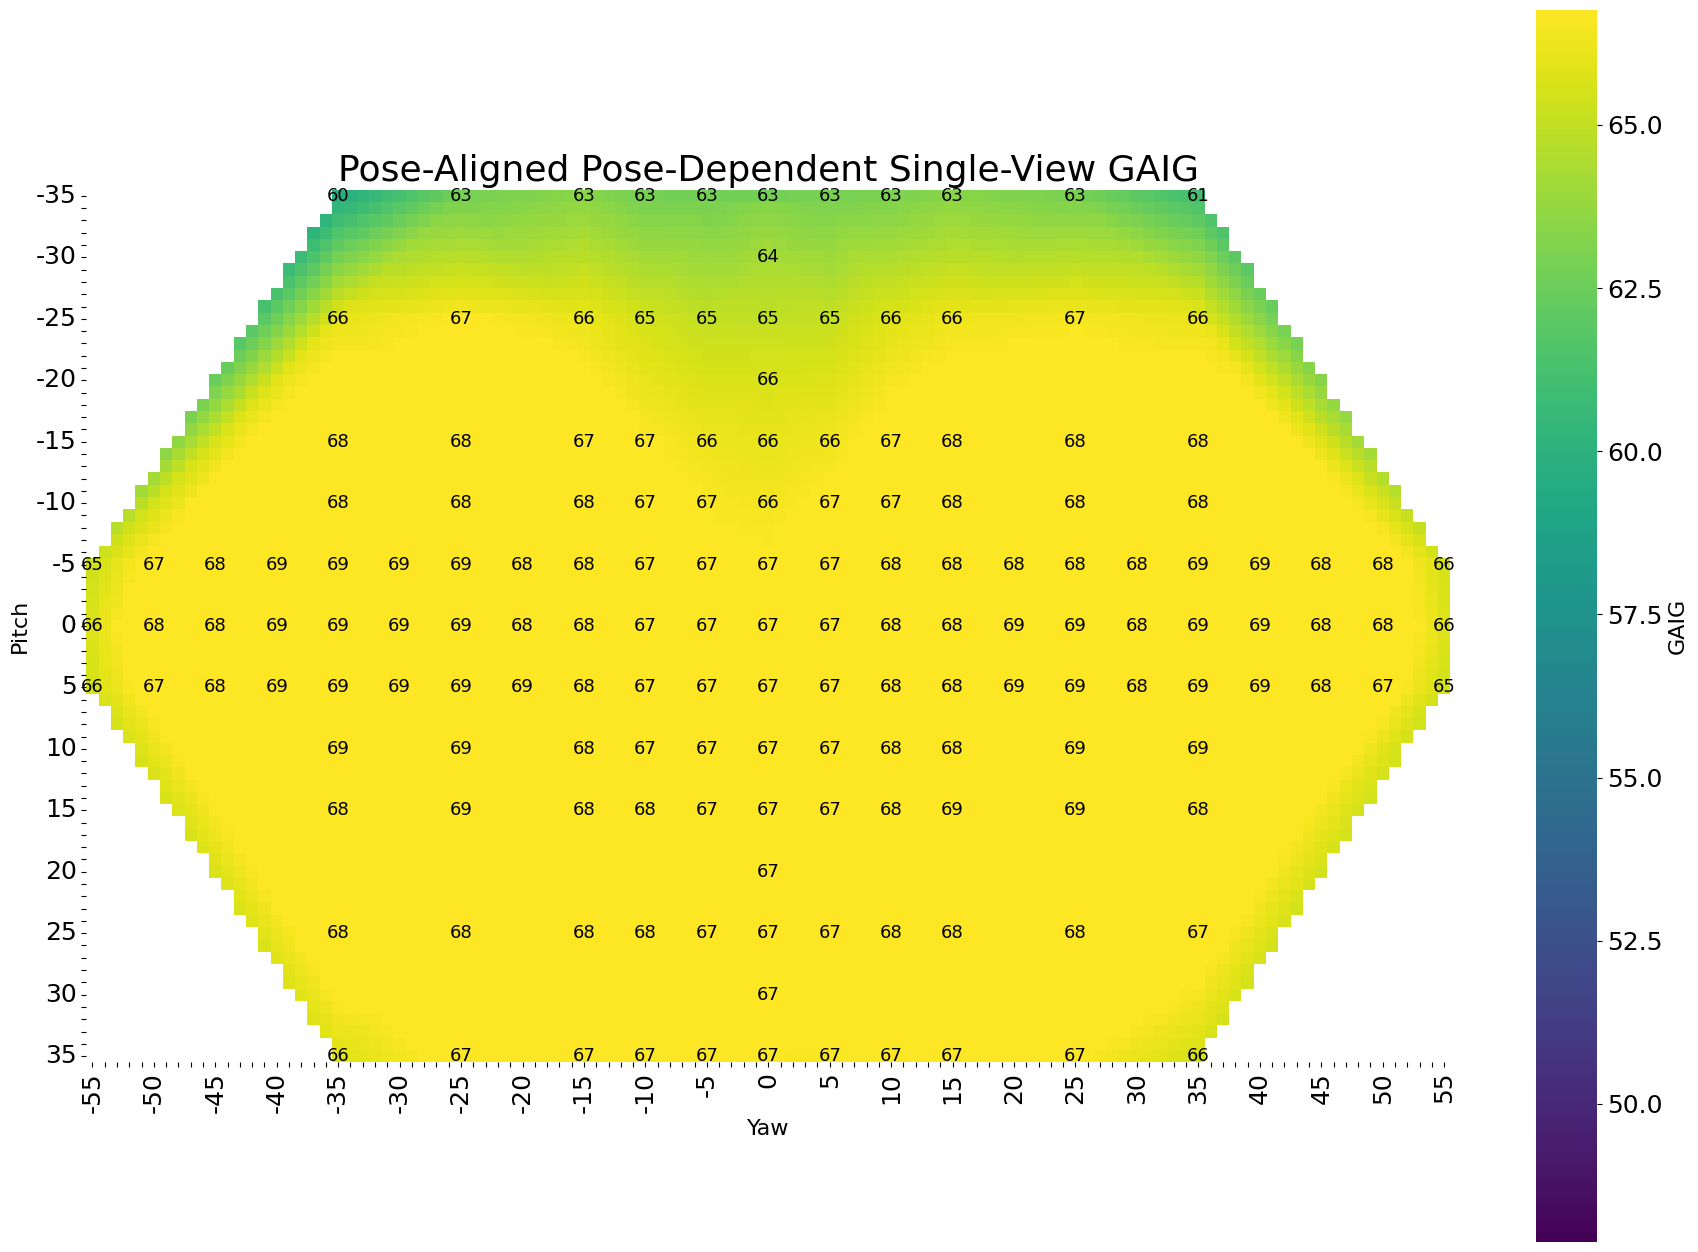

In [7]:
name="test_rgb_bff_crop305_emb-vit"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_gaig, pitches, yaws, heatmap_min, heatmap_max = compute_gaig_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_gaig, pitches, yaws = compute_gaig_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name, vmin=heatmap_min, vmax=heatmap_max)